In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import scipy.stats
import warnings
from scipy.stats import norm
warnings.filterwarnings("ignore")
pd.options.display.float_format = '{:.3f}'.format

import pmdarima as pm
import arch
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.forecasting.stl import STLForecast
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from statsmodels.distributions.empirical_distribution import ECDF


def remove_high_pvalue_features(X, y, threshold=0.05, verbose=True):
    """
    OLS 회귀를 통해 p-value가 높은 변수들을 반복적으로 제거하는 함수

    Parameters:
        X : DataFrame - 독립변수
        y : Series or DataFrame - 종속변수
        threshold : float - p-value 기준값 (default 0.05)
        verbose : bool - 제거 로그 출력 여부

    Returns:
        model : 최종 statsmodels 회귀 모델
        X_ols : 최종 남은 변수 DataFrame
    """
    X_ols = sm.add_constant(X).copy().reset_index(drop=True)
    y = y.reset_index(drop=True)

    model = sm.OLS(y, X_ols).fit()

    while True:
        pvalues = model.pvalues.drop('const', errors='ignore')
        max_p = pvalues.max()
        if max_p > threshold:
            drop_feature = pvalues.idxmax()
            if verbose:
                print(f"p-value {max_p:.4f}인 '{drop_feature}' 제거")
            X_ols = X_ols.drop(columns=drop_feature)
            y = y[:len(X_ols)].reset_index(drop=True)
            model = sm.OLS(y, X_ols).fit()
        else:
            break

    return model, X_ols

# 데이터 불러오기
original = pd.read_csv('c:\\python\\data2(filtered).csv', dtype={2: 'str'}).iloc[:,2:7]

original = original.reset_index(drop = True)
# 신고중량이 0으로 신고된 수입건 제외
original = original.drop(original[original['신고중량'] == 0].index)
# 1년간 수입한 일수가 100일 미만은 품목 제외
#year_ago = original['수리일자'].max() - 10000
#hs_hole = list(original[original['수리일자'] > year_ago]['HS10단위부호'].value_counts()[original[original['수리일자'] > year_ago]['HS10단위부호'].value_counts() < 100].index)
#original = original[~original['HS10단위부호'].isin(hs_hole)]

# 연도_주차 구하기
original['수리일자'] = original['수리일자'].astype(str)
original['수리일자'] = pd.to_datetime(original['수리일자'])
original['연도'] = original['수리일자'].dt.year
original['월'] = original['수리일자'].dt.month
original['주차'] = original['수리일자'].dt.isocalendar().week
original['연도주차'] = original['연도'] * 100 + original['주차']
original['연도주차'][(original['월'] == 1) & (original['주차'] > 5)] -= 100
original['연도주차'][(original['월'] == 12) & (original['주차'] < 5)] += 100
original['연도주차'] = original['연도주차'].apply(lambda x : str(x)[2:4] + '_' + str(x)[4:])

# 전체 연도_주차 데이터 생성
date_index = original['연도주차'].unique()
# 사용하는 컬럼 정리
use_col = ['HS10단위부호', '연도주차', '무역거래처국가코드', '신고중량', '과세가격미화금액']

# 외생변수 불러오기
exog_data = pd.read_csv('c:\\python\\Select_variables11.csv').reset_index(drop=True)
exog_columns = exog_data.columns.tolist()

p_eriod = -52

HS Code : 3102109000
      연도주차    단가         신고중량
0    17_04 0.255  5332959.546
1    17_05 0.262  6013912.829
2    17_06 0.266  5785572.955
3    17_07 0.274  6293268.930
4    17_08 0.273  5994605.184
..     ...   ...          ...
292  22_34 0.685 15555657.293
293  22_35 0.675 15785998.656
294  22_36 0.667 13272932.558
295  22_37 0.668 13644743.548
296  22_38 0.678  8370437.638

[297 rows x 3 columns]
         KOR_1  KOR_18     KOR_2       KOR_3  KOR_4  KOR_5  KOR_6  KOR_7  \
0   176219.674  22.144 19897.716  757442.376 24.874 23.804 23.932 21.040   
1   176454.419  22.213 20038.968  758508.890 24.938 23.915 23.795 20.332   
2   179603.742  22.655 20453.563  773293.021 25.346 24.272 24.264 20.891   
3   184012.793  23.273 21033.996  793990.805 25.916 24.772 24.919 21.674   
4   188421.845  23.892 21614.429  814688.589 26.487 25.272 25.575 22.458   
..         ...     ...       ...         ...    ...    ...    ...    ...   
292 301778.355  26.295 37153.516 1155595.203 30.423 33.799 19.8

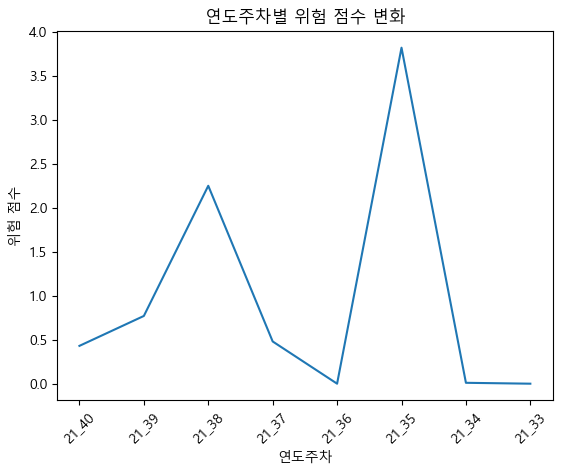

HS Code : 3707901010
      연도주차      단가      신고중량
0    17_04 219.044 17693.709
1    17_05 213.153 21010.400
2    17_06 216.113 19536.734
3    17_07 227.025 18619.221
4    17_08 223.977 18453.471
..     ...     ...       ...
292  22_34 414.585 19852.651
293  22_35 379.294 22915.441
294  22_36 378.936 22876.105
295  22_37 377.473 23998.908
296  22_38 338.724 23399.665

[297 rows x 3 columns]
         KOR_1  KOR_18     KOR_2       KOR_3  KOR_4  KOR_5  KOR_6  KOR_7  \
0   176219.674  22.144 19897.716  757442.376 24.874 23.804 23.932 21.040   
1   176454.419  22.213 20038.968  758508.890 24.938 23.915 23.795 20.332   
2   179603.742  22.655 20453.563  773293.021 25.346 24.272 24.264 20.891   
3   184012.793  23.273 21033.996  793990.805 25.916 24.772 24.919 21.674   
4   188421.845  23.892 21614.429  814688.589 26.487 25.272 25.575 22.458   
..         ...     ...       ...         ...    ...    ...    ...    ...   
292 301778.355  26.295 37153.516 1155595.203 30.423 33.799 19.898 21.937   

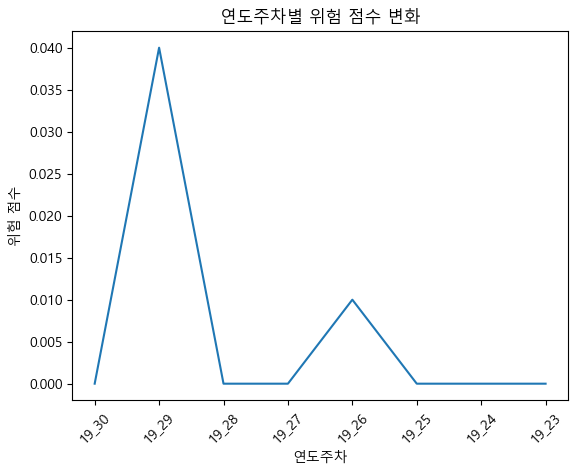

HS Code : 4407191000
      연도주차    단가       신고중량
0    17_04 1.321 239293.247
1    17_05 1.320 250460.747
2    17_06 1.335 267243.948
3    17_07 1.353 205743.000
4    17_08 1.355 166353.875
..     ...   ...        ...
292  22_34 1.459  46860.691
293  22_35 1.597  55567.169
294  22_36 1.587  60067.169
295  22_37 1.328  54362.169
296  22_38 1.313  49607.857

[297 rows x 3 columns]
         KOR_1  KOR_18     KOR_2       KOR_3  KOR_4  KOR_5  KOR_6  KOR_7  \
0   176219.674  22.144 19897.716  757442.376 24.874 23.804 23.932 21.040   
1   176454.419  22.213 20038.968  758508.890 24.938 23.915 23.795 20.332   
2   179603.742  22.655 20453.563  773293.021 25.346 24.272 24.264 20.891   
3   184012.793  23.273 21033.996  793990.805 25.916 24.772 24.919 21.674   
4   188421.845  23.892 21614.429  814688.589 26.487 25.272 25.575 22.458   
..         ...     ...       ...         ...    ...    ...    ...    ...   
292 301778.355  26.295 37153.516 1155595.203 30.423 33.799 19.898 21.937   
293 302764.

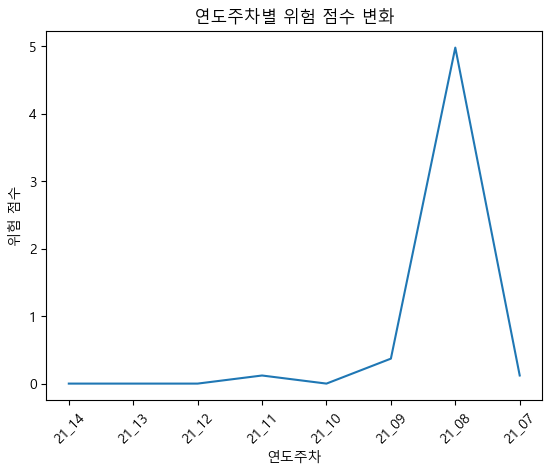

HS Code : 8111000000
      연도주차    단가        신고중량
0    17_04 2.294 1589538.823
1    17_05 2.322 1797062.025
2    17_06 2.349 2135029.125
3    17_07 2.255 2589847.688
4    17_08 2.222 2647460.135
..     ...   ...         ...
292  22_34 2.417 1887338.301
293  22_35 2.470 1322372.493
294  22_36 2.402 1172857.531
295  22_37 2.328 1437803.669
296  22_38 2.315  991759.689

[297 rows x 3 columns]
         KOR_1  KOR_18     KOR_2       KOR_3  KOR_4  KOR_5  KOR_6  KOR_7  \
0   176219.674  22.144 19897.716  757442.376 24.874 23.804 23.932 21.040   
1   176454.419  22.213 20038.968  758508.890 24.938 23.915 23.795 20.332   
2   179603.742  22.655 20453.563  773293.021 25.346 24.272 24.264 20.891   
3   184012.793  23.273 21033.996  793990.805 25.916 24.772 24.919 21.674   
4   188421.845  23.892 21614.429  814688.589 26.487 25.272 25.575 22.458   
..         ...     ...       ...         ...    ...    ...    ...    ...   
292 301778.355  26.295 37153.516 1155595.203 30.423 33.799 19.898 21.937   

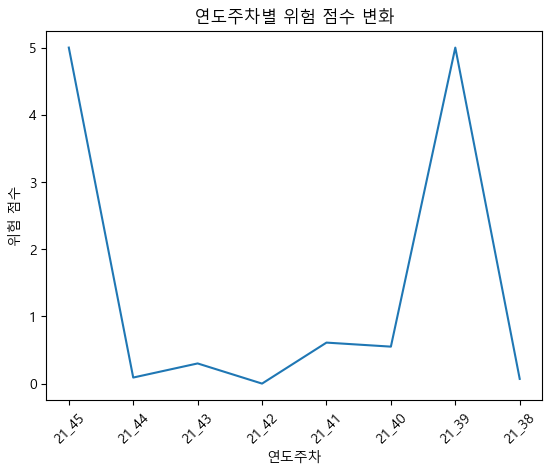

HS Code : 2701129010
      연도주차    단가          신고중량
0    17_04 0.177 163414532.500
1    17_05 0.183 128339537.000
2    17_06 0.187  77542167.000
3    17_07 0.178  87019096.075
4    17_08 0.165 107989167.275
..     ...   ...           ...
292  22_34 0.285 145518255.411
293  22_35 0.274 197342702.911
294  22_36 0.280 214007115.594
295  22_37 0.268 198569715.141
296  22_38 0.273 160074550.041

[297 rows x 3 columns]
         KOR_1  KOR_18     KOR_2       KOR_3  KOR_4  KOR_5  KOR_6  KOR_7  \
0   176219.674  22.144 19897.716  757442.376 24.874 23.804 23.932 21.040   
1   176454.419  22.213 20038.968  758508.890 24.938 23.915 23.795 20.332   
2   179603.742  22.655 20453.563  773293.021 25.346 24.272 24.264 20.891   
3   184012.793  23.273 21033.996  793990.805 25.916 24.772 24.919 21.674   
4   188421.845  23.892 21614.429  814688.589 26.487 25.272 25.575 22.458   
..         ...     ...       ...         ...    ...    ...    ...    ...   
292 301778.355  26.295 37153.516 1155595.203 30.423

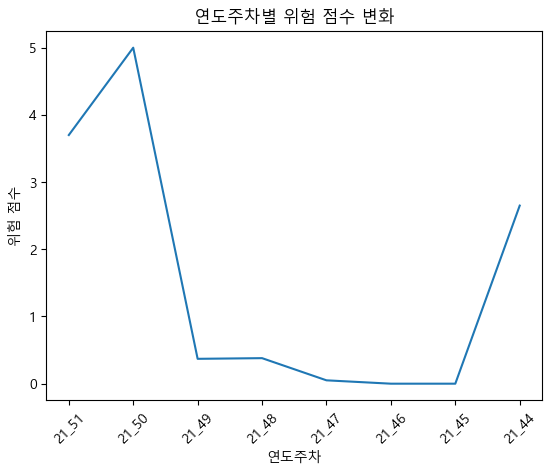

HS Code : 2804701000
      연도주차    단가       신고중량
0    17_04 2.811 160032.550
1    17_05 2.856 164322.550
2    17_06 2.862 142277.500
3    17_07 2.849 143690.000
4    17_08 2.827 128430.000
..     ...   ...        ...
292  22_34 7.502 144652.712
293  22_35 7.193 160465.212
294  22_36 7.270 198465.212
295  22_37 7.206 209505.000
296  22_38 7.230 164662.500

[297 rows x 3 columns]
         KOR_1  KOR_18     KOR_2       KOR_3  KOR_4  KOR_5  KOR_6  KOR_7  \
0   176219.674  22.144 19897.716  757442.376 24.874 23.804 23.932 21.040   
1   176454.419  22.213 20038.968  758508.890 24.938 23.915 23.795 20.332   
2   179603.742  22.655 20453.563  773293.021 25.346 24.272 24.264 20.891   
3   184012.793  23.273 21033.996  793990.805 25.916 24.772 24.919 21.674   
4   188421.845  23.892 21614.429  814688.589 26.487 25.272 25.575 22.458   
..         ...     ...       ...         ...    ...    ...    ...    ...   
292 301778.355  26.295 37153.516 1155595.203 30.423 33.799 19.898 21.937   
293 302764.

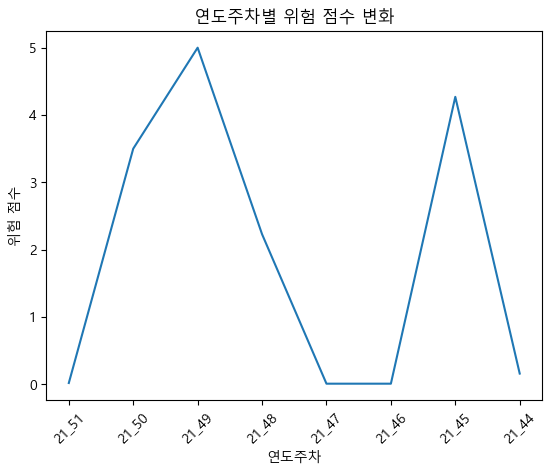

HS Code : 1511901000
      연도주차    단가        신고중량
0    17_04 0.735  936849.355
1    17_05 0.734  930738.055
2    17_06 0.754  893311.305
3    17_07 0.756 1637404.305
4    17_08 0.774 1212247.700
..     ...   ...         ...
292  22_34 1.468  759382.356
293  22_35 1.501  785201.626
294  22_36 1.488  774298.645
295  22_37 1.569  271958.020
296  22_38 1.391  698774.770

[297 rows x 3 columns]
         KOR_1  KOR_18     KOR_2       KOR_3  KOR_4  KOR_5  KOR_6  KOR_7  \
0   176219.674  22.144 19897.716  757442.376 24.874 23.804 23.932 21.040   
1   176454.419  22.213 20038.968  758508.890 24.938 23.915 23.795 20.332   
2   179603.742  22.655 20453.563  773293.021 25.346 24.272 24.264 20.891   
3   184012.793  23.273 21033.996  793990.805 25.916 24.772 24.919 21.674   
4   188421.845  23.892 21614.429  814688.589 26.487 25.272 25.575 22.458   
..         ...     ...       ...         ...    ...    ...    ...    ...   
292 301778.355  26.295 37153.516 1155595.203 30.423 33.799 19.898 21.937   

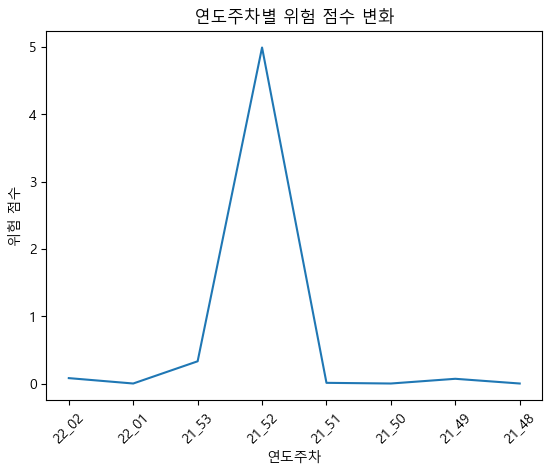

HS Code : 305531000
      연도주차     단가       신고중량
0    17_04 10.143 112739.000
1    17_05 10.020 106671.250
2    17_06  9.953 107973.500
3    17_07  9.665  98612.500
4    17_08  9.570  93437.500
..     ...    ...        ...
292  22_34 10.917 132790.114
293  22_35 10.543 146227.391
294  22_36 10.839 132587.659
295  22_37 10.828 108393.587
296  22_38 10.431  98649.147

[297 rows x 3 columns]
         KOR_1  KOR_18     KOR_2       KOR_3  KOR_4  KOR_5  KOR_6  KOR_7  \
0   176219.674  22.144 19897.716  757442.376 24.874 23.804 23.932 21.040   
1   176454.419  22.213 20038.968  758508.890 24.938 23.915 23.795 20.332   
2   179603.742  22.655 20453.563  773293.021 25.346 24.272 24.264 20.891   
3   184012.793  23.273 21033.996  793990.805 25.916 24.772 24.919 21.674   
4   188421.845  23.892 21614.429  814688.589 26.487 25.272 25.575 22.458   
..         ...     ...       ...         ...    ...    ...    ...    ...   
292 301778.355  26.295 37153.516 1155595.203 30.423 33.799 19.898 21.937   


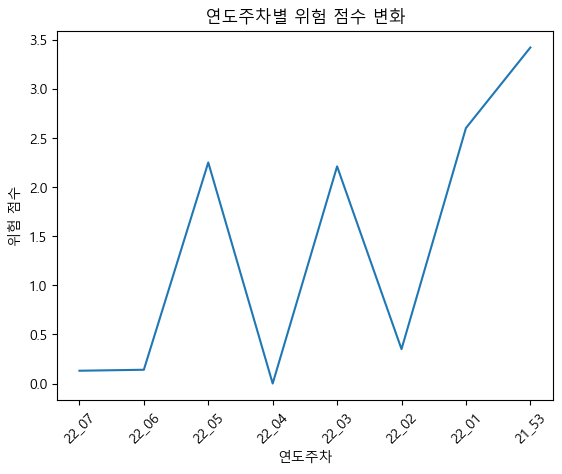

HS Code : 302140000
      연도주차     단가       신고중량
0    17_04 12.297 248997.765
1    17_05 11.776 247770.110
2    17_06 11.204 258943.758
3    17_07 10.781 262438.498
4    17_08 10.400 279016.205
..     ...    ...        ...
292  22_34 13.914 361472.777
293  22_35 13.643 378891.888
294  22_36 13.112 381338.341
295  22_37 12.738 381753.838
296  22_38 12.394 386434.054

[297 rows x 3 columns]
         KOR_1  KOR_18     KOR_2       KOR_3  KOR_4  KOR_5  KOR_6  KOR_7  \
0   176219.674  22.144 19897.716  757442.376 24.874 23.804 23.932 21.040   
1   176454.419  22.213 20038.968  758508.890 24.938 23.915 23.795 20.332   
2   179603.742  22.655 20453.563  773293.021 25.346 24.272 24.264 20.891   
3   184012.793  23.273 21033.996  793990.805 25.916 24.772 24.919 21.674   
4   188421.845  23.892 21614.429  814688.589 26.487 25.272 25.575 22.458   
..         ...     ...       ...         ...    ...    ...    ...    ...   
292 301778.355  26.295 37153.516 1155595.203 30.423 33.799 19.898 21.937   


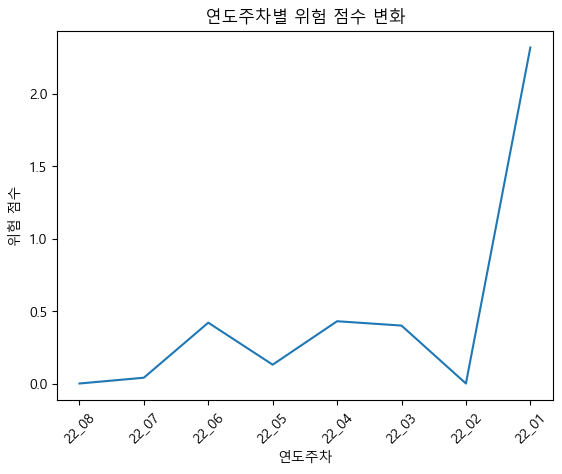

HS Code : 1003901000
      연도주차    단가        신고중량
0    17_04   NaN         NaN
1    17_05   NaN         NaN
2    17_06   NaN         NaN
3    17_07   NaN         NaN
4    17_08 0.288 1533750.000
..     ...   ...         ...
292  22_34 0.474  136245.000
293  22_35 0.442  384820.000
294  22_36 0.448  399849.500
295  22_37 0.461  360794.500
296  22_38 0.454  345794.500

[297 rows x 3 columns]
         KOR_1  KOR_18     KOR_2       KOR_3  KOR_4  KOR_5  KOR_6  KOR_7  \
0   176219.674  22.144 19897.716  757442.376 24.874 23.804 23.932 21.040   
1   176454.419  22.213 20038.968  758508.890 24.938 23.915 23.795 20.332   
2   179603.742  22.655 20453.563  773293.021 25.346 24.272 24.264 20.891   
3   184012.793  23.273 21033.996  793990.805 25.916 24.772 24.919 21.674   
4   188421.845  23.892 21614.429  814688.589 26.487 25.272 25.575 22.458   
..         ...     ...       ...         ...    ...    ...    ...    ...   
292 301778.355  26.295 37153.516 1155595.203 30.423 33.799 19.898 21.937   

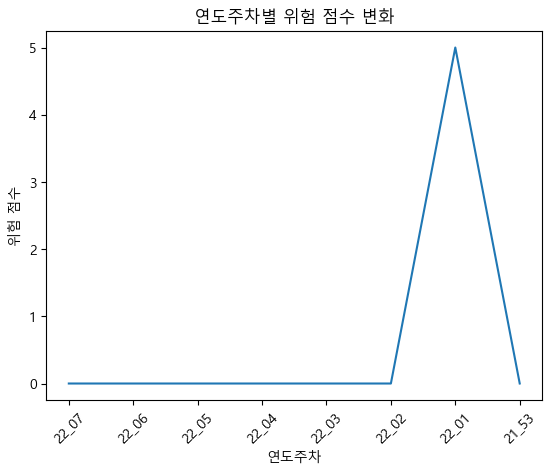

HS Code : 1003902000
      연도주차    단가        신고중량
0    17_04 0.192 3149912.500
1    17_05 0.192 3412412.500
2    17_06 0.192 2054420.000
3    17_07 0.192 1861815.000
4    17_08 0.192  354402.500
..     ...   ...         ...
292  22_34 0.383  183362.562
293  22_35 0.383  183362.562
294  22_36 0.366  116280.000
295  22_37 0.379   75557.500
296  22_38 0.379   75557.500

[297 rows x 3 columns]
         KOR_1  KOR_18     KOR_2       KOR_3  KOR_4  KOR_5  KOR_6  KOR_7  \
0   176219.674  22.144 19897.716  757442.376 24.874 23.804 23.932 21.040   
1   176454.419  22.213 20038.968  758508.890 24.938 23.915 23.795 20.332   
2   179603.742  22.655 20453.563  773293.021 25.346 24.272 24.264 20.891   
3   184012.793  23.273 21033.996  793990.805 25.916 24.772 24.919 21.674   
4   188421.845  23.892 21614.429  814688.589 26.487 25.272 25.575 22.458   
..         ...     ...       ...         ...    ...    ...    ...    ...   
292 301778.355  26.295 37153.516 1155595.203 30.423 33.799 19.898 21.937   

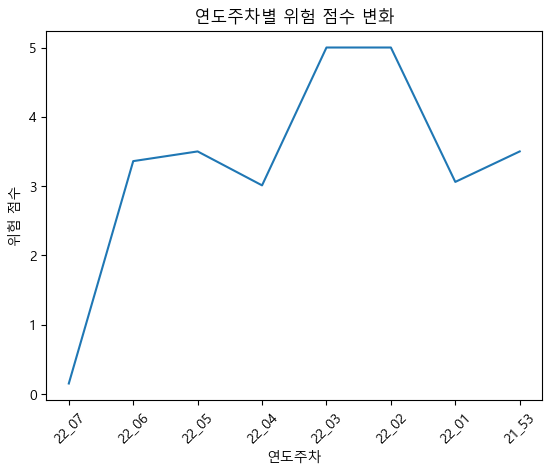

HS Code : 1104230000
      연도주차    단가       신고중량
0    17_04 0.389  38475.125
1    17_05 0.430 166375.125
2    17_06 0.477 415325.600
3    17_07 0.478 462700.475
4    17_08 0.475 537900.475
..     ...   ...        ...
292  22_34 0.451 446502.199
293  22_35 0.448 560500.000
294  22_36 0.447 413250.000
295  22_37 0.465 337250.000
296  22_38 0.473 231750.000

[297 rows x 3 columns]
         KOR_1  KOR_18     KOR_2       KOR_3  KOR_4  KOR_5  KOR_6  KOR_7  \
0   176219.674  22.144 19897.716  757442.376 24.874 23.804 23.932 21.040   
1   176454.419  22.213 20038.968  758508.890 24.938 23.915 23.795 20.332   
2   179603.742  22.655 20453.563  773293.021 25.346 24.272 24.264 20.891   
3   184012.793  23.273 21033.996  793990.805 25.916 24.772 24.919 21.674   
4   188421.845  23.892 21614.429  814688.589 26.487 25.272 25.575 22.458   
..         ...     ...       ...         ...    ...    ...    ...    ...   
292 301778.355  26.295 37153.516 1155595.203 30.423 33.799 19.898 21.937   
293 302764.

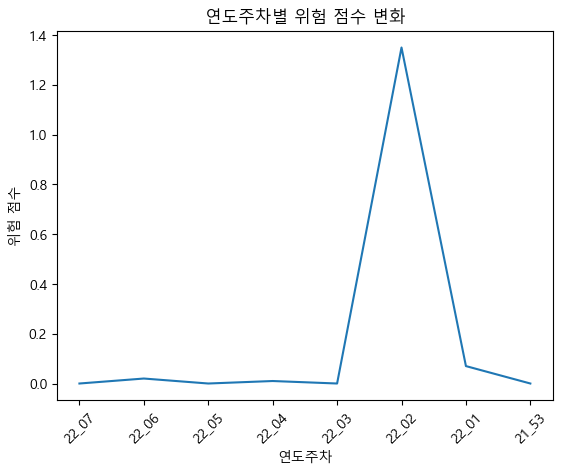

HS Code : 2710121000
      연도주차    단가         신고중량
0    17_04 0.551  2149886.250
1    17_05 0.550  4114309.500
2    17_06 0.549  6381111.750
3    17_07 0.549  4234150.250
4    17_08 0.547  9687853.750
..     ...   ...          ...
292  22_34 0.801 16626932.000
293  22_35 0.955  9728367.250
294  22_36 0.916  8810688.000
295  22_37 0.916  8810688.000
296  22_38 0.713 14231087.750

[297 rows x 3 columns]
         KOR_1  KOR_18     KOR_2       KOR_3  KOR_4  KOR_5  KOR_6  KOR_7  \
0   176219.674  22.144 19897.716  757442.376 24.874 23.804 23.932 21.040   
1   176454.419  22.213 20038.968  758508.890 24.938 23.915 23.795 20.332   
2   179603.742  22.655 20453.563  773293.021 25.346 24.272 24.264 20.891   
3   184012.793  23.273 21033.996  793990.805 25.916 24.772 24.919 21.674   
4   188421.845  23.892 21614.429  814688.589 26.487 25.272 25.575 22.458   
..         ...     ...       ...         ...    ...    ...    ...    ...   
292 301778.355  26.295 37153.516 1155595.203 30.423 33.799 19.8

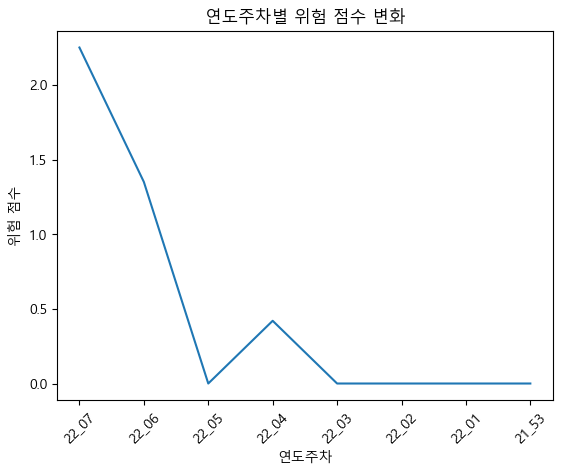

HS Code : 3104200000
      연도주차    단가         신고중량
0    17_04 0.299 11374102.375
1    17_05 0.298 16317880.400
2    17_06 0.291 12415604.100
3    17_07 0.291 10819745.700
4    17_08 0.289 11582318.950
..     ...   ...          ...
292  22_34 0.992 29386228.624
293  22_35 1.007  9666683.242
294  22_36 1.006  9627907.123
295  22_37 1.007  9785683.655
296  22_38 1.010  2767031.598

[297 rows x 3 columns]
         KOR_1  KOR_18     KOR_2       KOR_3  KOR_4  KOR_5  KOR_6  KOR_7  \
0   176219.674  22.144 19897.716  757442.376 24.874 23.804 23.932 21.040   
1   176454.419  22.213 20038.968  758508.890 24.938 23.915 23.795 20.332   
2   179603.742  22.655 20453.563  773293.021 25.346 24.272 24.264 20.891   
3   184012.793  23.273 21033.996  793990.805 25.916 24.772 24.919 21.674   
4   188421.845  23.892 21614.429  814688.589 26.487 25.272 25.575 22.458   
..         ...     ...       ...         ...    ...    ...    ...    ...   
292 301778.355  26.295 37153.516 1155595.203 30.423 33.799 19.8

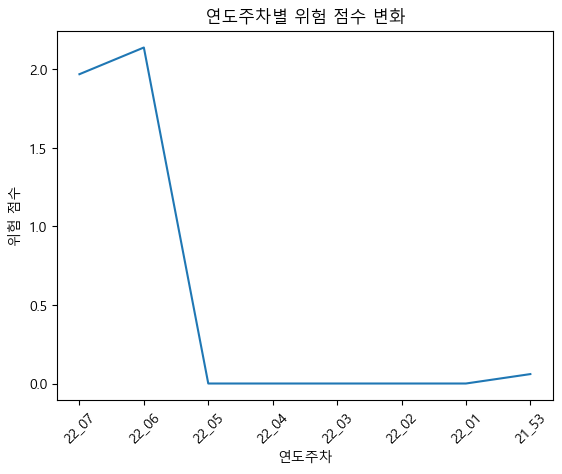

HS Code : 2905172000
      연도주차    단가       신고중량
0    17_04 1.801  49211.300
1    17_05 1.754  65983.925
2    17_06 1.838  79977.625
3    17_07 1.857  61760.131
4    17_08 1.863  63759.256
..     ...   ...        ...
292  22_34 3.054 100640.853
293  22_35 3.011 131752.708
294  22_36 2.871 136344.133
295  22_37 2.882  95667.133
296  22_38 2.817  62904.505

[297 rows x 3 columns]
         KOR_1  KOR_18     KOR_2       KOR_3  KOR_4  KOR_5  KOR_6  KOR_7  \
0   176219.674  22.144 19897.716  757442.376 24.874 23.804 23.932 21.040   
1   176454.419  22.213 20038.968  758508.890 24.938 23.915 23.795 20.332   
2   179603.742  22.655 20453.563  773293.021 25.346 24.272 24.264 20.891   
3   184012.793  23.273 21033.996  793990.805 25.916 24.772 24.919 21.674   
4   188421.845  23.892 21614.429  814688.589 26.487 25.272 25.575 22.458   
..         ...     ...       ...         ...    ...    ...    ...    ...   
292 301778.355  26.295 37153.516 1155595.203 30.423 33.799 19.898 21.937   
293 302764.

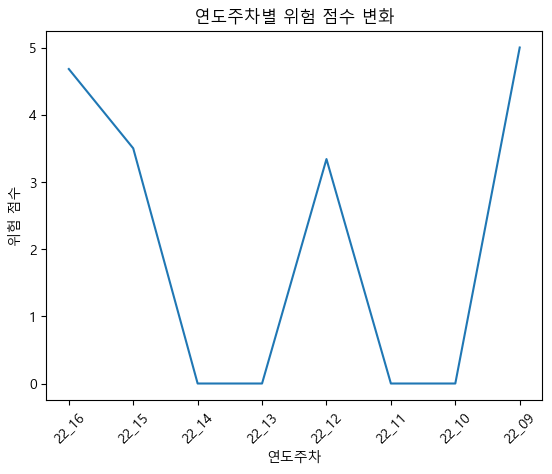

[np.float64(3.82), np.float64(0.04), np.float64(4.98), np.float64(5.0), np.float64(5.0), np.float64(5.0), np.float64(4.99), np.float64(3.42), np.float64(2.32), np.float64(5.0), np.float64(5.0), np.float64(1.35), np.float64(2.25), np.float64(2.14), np.float64(5.0)]
[56, 167, 83, 46, 41, 42, 39, 38, 37, 37, 35, 36, 31, 32, 29]


In [ ]:
추출용 = [3102109000,3707901010,4407191000,8111000000,2701129010,2804701000,1511901000,305531000,302140000,1003901000,1003902000,1104230000,2710121000,3104200000,2905172000]
b = [59, 174, 85, 54, 48, 48, 44, 39, 38, 39, 39, 39, 39, 39, 30]

z = []
c = []
e = []
k = []
o = []
z_x = []
z_y = []

for i in range(0, len(추출용)):
  z.append(0) # 품목별 Highest CV를 반영하기 위해 List 생성
  c.append(0) # 품목별 CV값이 임계값 이상인 경우의 횟수를 반영하기 위한 List 생성
  k.append(0) # 임계값을 넘는 횟수
  o.append(0) # 위험경보 여부
  z_x.append(0) # Highest CV의 X값
  z_y.append(0) # Highest CV의 y값

for i in range(0, 8):
  e.append(0) # 품목별 8주간 CV값을 반영하기 위한 List 생성성
  
j = 0

for i in 추출용:
    print(f'HS Code : {i}')
    original[original['HS10단위부호'] == str(i)].sort_values(by = '수리일자', ascending = False)
    data = pd.DataFrame(columns = use_col)
    data = pd.concat([data, original[original['HS10단위부호'] == str(i)]])
    data = data.reset_index(drop=True)

    data = data.sort_values(by='수리일자', ascending=True).reset_index(drop=True)
    
    #
    ## 최근 52주간 수입단가(직전4주평균) 추이 파악
    #
    df_price = data[['연도주차', '과세가격미화금액', '신고중량']]
    df_price_week = df_price.groupby('연도주차')[['과세가격미화금액', '신고중량']].agg(['sum']).reset_index()
    df_price_week.columns = ['연도주차', '과세가격미화금액', '신고중량']


    # 수입이 없는 주차의 값을 0으로 생성
    df_price_week_hole = pd.DataFrame(columns = df_price_week.columns)
    for wk in set(date_index) - set(df_price_week['연도주차'].unique()):
        df_price_week_hole = pd.concat([df_price_week_hole, pd.DataFrame([{'연도주차': wk, '과세가격미화금액': 0, '신고중량': 0}])], ignore_index=True)
    df_price_week_total = pd.concat([df_price_week, df_price_week_hole]).sort_values('연도주차')

    # 해당 주차의 데이터를 직전 4주간 평균으로 대체
    price_w4 = []
    kg_w4 = []
    for x in range(0, len(df_price_week_total) - 3):
        price_w4.append(df_price_week_total[['과세가격미화금액']].iloc[x : x + 4].mean().iloc[0])
        kg_w4.append(df_price_week_total[['신고중량']].iloc[x : x + 4].mean().iloc[0])
    df_price_4w = df_price_week_total[3:]
    df_price_4w['과세가격미화금액'] = price_w4
    df_price_4w['신고중량'] = kg_w4
    df_price_4w = df_price_4w.reset_index(drop = True)
    df_price_4w['과세가격미화금액'] = df_price_4w['과세가격미화금액'].replace(0, np.nan).ffill()
    df_price_4w['신고중량'] = df_price_4w['신고중량'].replace(0, np.nan).ffill()
    df_price_4w['단가'] = df_price_4w['과세가격미화금액'] / df_price_4w['신고중량']
    df_price_4w = df_price_4w[['연도주차', '단가', '신고중량']]
    print(df_price_4w)
    
    exog_w4 = []
    for x in range(0, len(exog_data) - 3):
        mean_vals = exog_data[x : x + 4].mean(axis=0)  # 각 열(column)에 대한 평균
        exog_w4.append(mean_vals)
        
    df_exog_4w = pd.DataFrame(exog_w4, columns=exog_columns)
    df_exog_4w = df_exog_4w.reset_index(drop=True)
    df_exog_4w = df_exog_4w.iloc[-len(df_price_4w):].reset_index(drop=True)
    print(df_exog_4w)
    
    X = df_exog_4w.select_dtypes(include=[np.number])
    scaler_exog_vif = StandardScaler()
    X_scaled = pd.DataFrame(scaler_exog_vif.fit_transform(X), columns=X.columns)   
    print("x", X_scaled) 

    y = df_price_4w['단가'].reset_index(drop=True)
    y1 = df_price_4w['신고중량'].reset_index(drop=True)
    scaler_y = StandardScaler()
    y_scaled = scaler_y.fit_transform(y.values.reshape(-1, 1)).flatten()    
    scaler_y1 = StandardScaler()
    y1_scaled = scaler_y1.fit_transform(y1.values.reshape(-1, 1)).flatten()

    # -----------------------------
    # 2. VIF 제거 (반복)
    # -----------------------------
    def calculate_vif(df):
        vif_data = pd.DataFrame()
        vif_data["Feature"] = df.columns
        vif_data["VIF"] = [variance_inflation_factor(df.values, i) for i in range(df.shape[1])]
        return vif_data

    X_vif = X_scaled.copy()
    while True:
        vif_df = calculate_vif(X_vif)
        max_vif = vif_df['VIF'].max()
        if max_vif > 10:
            drop_feature = vif_df.sort_values('VIF', ascending=False)['Feature'].iloc[0]
            print(f"VIF {max_vif:.2f}인 '{drop_feature}' 제거")
            X_vif = X_vif.drop(columns=drop_feature)
        else:
            break

    # -----------------------------
    # 3. OLS 회귀로 p-value 높은 변수 제거(단가)
    # -----------------------------
        
    # 함수 적용
    model, final_X = remove_high_pvalue_features(X_vif, pd.Series(y_scaled), threshold=0.1)

    # 결과 출력
    print("최종 변수 목록:", final_X.columns.tolist())
    print(model.summary())
    columns_without_const = [col for col in final_X.columns if col != 'const']
    if not columns_without_const:
        columns_without_const = ['KOR_1']
    df_exog_4w0 = df_exog_4w[columns_without_const].copy()

    
    # -----------------------------
    # 3. OLS 회귀로 p-value 높은 변수 제거(신고중량)
    # -----------------------------
        
    # 함수 적용
    model1, final_X1 = remove_high_pvalue_features(X_vif, pd.Series(y1_scaled), threshold=0.1)

    # 결과 출력
    print("최종 변수 목록:", final_X1.columns.tolist())
    print(model1.summary())
    columns_without_const1 = [col for col in final_X1.columns if col != 'const']
    if not columns_without_const1:
        columns_without_const1 = ['KOR_1']
    df_exog_4w1 = df_exog_4w[columns_without_const1].copy()
    
    
    for l in range(b[j]-8,b[j]):

        print(df_price_4w['연도주차'].iloc[-1-l] + '주차')
        #=================== 단가 percertile 구하기 ====================
        ecdf = ECDF(df_price_4w.iloc[p_eriod-l:-l]['단가'])
        y=np.exp((ecdf(df_price_4w.iloc[-1-l]['단가'])*100 - 95)*np.log(5)/5)
        
      #=================== 신고중량 ======================
         
        res_resid = df_price_4w['신고중량'].iloc[p_eriod-l:-l]
        res_resid = res_resid.reset_index(drop=True)
        exog_var = df_exog_4w1.iloc[p_eriod-l:-l]
        exog_var = exog_var.reset_index(drop=True)
        
        print(res_resid)
        print(exog_var)
        n_test = 1
        
        train_y, test_y = res_resid[:-n_test], res_resid[-n_test:]
        train_x, test_x = exog_var[:-n_test], exog_var[-n_test:]
        
        # 1) y와 X를 같이 붙여서 정리
        train_all = pd.concat(
            [pd.Series(train_y).rename('y'),
            pd.DataFrame(train_x).reset_index(drop=True)],
            axis=1
        )

        train_all = train_all.apply(pd.to_numeric, errors='coerce')
        train_all = train_all.replace([np.inf, -np.inf], np.nan)
        train_all = train_all.bfill().ffill().dropna().reset_index(drop=True)

        # test도 같은 방식
        test_all = pd.concat(
            [pd.Series(test_y).rename('y'),
            pd.DataFrame(test_x).reset_index(drop=True)],
            axis=1
        )

        test_all = test_all.apply(pd.to_numeric, errors='coerce')
        test_all = test_all.replace([np.inf, -np.inf], np.nan)
        test_all = test_all.bfill().ffill().dropna().reset_index(drop=True)

        # 2) 최소 길이 검사
        if len(train_all) < 10:
            print("train 데이터가 너무 짧아서 skip")
            continue

        # 3) y가 상수열이면 skip
        if train_all['y'].nunique() <= 1:
            print("train_y가 상수열이라 skip")
            continue

        # 4) 다시 분리
        train_y_clean = train_all['y']
        train_x_clean = train_all.drop(columns='y')

        test_y_clean = test_all['y']
        test_x_clean = test_all.drop(columns='y')

        # 5) 스케일링
        scaler_y = StandardScaler()
        scaler_x = StandardScaler()

        train_y_scaled = scaler_y.fit_transform(train_y_clean.values.reshape(-1, 1)).ravel()
        test_y_scaled  = scaler_y.transform(test_y_clean.values.reshape(-1, 1)).ravel()

        train_x_scaled = scaler_x.fit_transform(train_x_clean.values)
        test_x_scaled  = scaler_x.transform(test_x_clean.values)

        model = pm.auto_arima(train_y_scaled, exogenous=train_x_scaled, seasonal=False, trace=True)
        p, d, q = model.order

        model = SARIMAX(train_y_scaled, exog=train_x_scaled, order=(p, d, q), seasonal_order=(1, 1, 1, 12), 
                        enforce_stationarity=False, enforce_invertibility=False)
        model_fit = model.fit(disp=False)
        forecast1 = model_fit.forecast(steps=1, exog=test_x_scaled[-1:])
                
        print('======================= 여기부터 GARCH 모델링 =================================')
        est_residuals = model_fit.resid
        garch = arch.arch_model(est_residuals, vol="GARCH", p=1, q=1)
        garch_fit = garch.fit(disp="off", options={"maxiter": 1000})
        
        print('=========== GARCH forecast =============')
        garch_forecast = garch_fit.forecast(horizon = n_test, reindex=True)
        garch_std = np.sqrt(garch_forecast.variance.iloc[-1,0])
        stand_quant = (test_y_scaled[0] - forecast1[0])/ garch_std

        if(scipy.stats.norm.cdf(stand_quant)>0.5):
            x=np.exp((scipy.stats.norm.cdf(stand_quant)*100 - 95)*np.log(5)/5)
        else:
            x=np.exp(((1-scipy.stats.norm.cdf(stand_quant))*100 - 95)*np.log(5)/5)
        
        e[(l-b[j]+8)] = round(2/(1/y+1/x), 2)
        if(round(2/(1/y+1/x), 2)>1.85):
            k[j] += 1
        if(z[j] < round(2/(1/y+1/x), 2)):
            z[j] = round(2/(1/y+1/x), 2)
            c[j] = l
            
        if(z_x[j] < x):
            z_x[j] = x
            
        if(z_y[j] < y):
            z_y[j] = y
      
    if(z[j]>1.85):
        o[j] = 1
 
    import matplotlib.font_manager as fm

    plt.rc('font', family='Malgun Gothic')  # Windows (맑은 고딕)
    plt.rc('axes', unicode_minus=False)  # 마이너스(-) 기호 깨짐 방지
    
    x_labels = [df_price_4w['연도주차'].iloc[-1-l] for l in range(b[j]-8,b[j])]  # x축 라벨 생성
    plt.plot(x_labels, e)  # x축을 연도주차 값으로 설정
    plt.xticks(rotation=45)  # x축 라벨 회전 (가독성 개선)
    plt.xlabel("연도주차")  # x축 제목 추가
    plt.ylabel("위험 점수")  # y축 제목 추가
    plt.title("연도주차별 위험 점수 변화")  # 그래프 제목 추가
    plt.show()
    
    j += 1
print(z)
print(c)


# 구글드라이브에 있는 엑셀 파일을 불러와서 점수결과 저장하기
collect = pd.read_excel('c:\python\Compare_Models.xlsx', sheet_name="점수")
collect = pd.DataFrame(collect)
collect.loc[:14, 'Model18(1)'] = o
collect.loc[15, 'Model18(1)'] = np.sum(o)
collect.loc[:14, 'Model18(2)'] = z
collect.loc[15, 'Model18(2)'] = np.mean(z)
collect.to_excel('c:\python\Compare_Models.xlsx', sheet_name="점수", index=False)

collect1 = pd.read_excel('c:\python\Collectroc(t).xlsx', sheet_name="점수")
collect1 = pd.DataFrame(collect1)
collect1.loc[:14, 'y_scores[19]'] = z
collect1.to_excel('c:\python\Collectroc(t).xlsx', sheet_name="점수", index=False)

collect2 = pd.read_excel('c:\python\Collectroc(x).xlsx', sheet_name="점수")
collect2 = pd.DataFrame(collect2)
collect2.loc[:14, 'y_scores[19]'] = z_x
collect2.to_excel('c:\python\Collectroc(x).xlsx', sheet_name="점수", index=False)

collect3 = pd.read_excel('c:\python\Collectroc(y).xlsx', sheet_name="점수")
collect3 = pd.DataFrame(collect3)
collect3.loc[:14, 'y_scores[19]'] = z_y
collect3.to_excel('c:\python\Collectroc(y).xlsx', sheet_name="점수", index=False)

HS Code : 3926909000
         KOR_1  KOR_18     KOR_2       KOR_3  KOR_4  KOR_5  KOR_6  KOR_7  \
0   176219.674  22.144 19897.716  757442.376 24.874 23.804 23.932 21.040   
1   176454.419  22.213 20038.968  758508.890 24.938 23.915 23.795 20.332   
2   179603.742  22.655 20453.563  773293.021 25.346 24.272 24.264 20.891   
3   184012.793  23.273 21033.996  793990.805 25.916 24.772 24.919 21.674   
4   188421.845  23.892 21614.429  814688.589 26.487 25.272 25.575 22.458   
..         ...     ...       ...         ...    ...    ...    ...    ...   
292 301778.355  26.295 37153.516 1155595.203 30.423 33.799 19.898 21.937   
293 302764.441  26.423 37425.528 1161620.931 30.694 34.127 19.975 22.135   
294 304490.093  26.647 37901.548 1172165.954 31.169 34.701 20.111 22.481   
295 306215.744  26.871 38377.568 1182710.978 31.643 35.276 20.246 22.827   
296 307941.395  27.094 38853.588 1193256.001 32.118 35.850 20.382 23.173   

     KOR_8  KOR_9  ...      DJIA  NASDAQCOM   KOR_10  KOR_11  KOR_

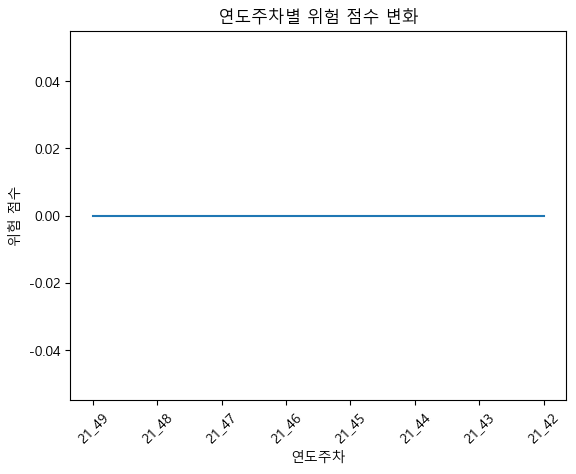

HS Code : 7326909000
         KOR_1  KOR_18     KOR_2       KOR_3  KOR_4  KOR_5  KOR_6  KOR_7  \
0   176219.674  22.144 19897.716  757442.376 24.874 23.804 23.932 21.040   
1   176454.419  22.213 20038.968  758508.890 24.938 23.915 23.795 20.332   
2   179603.742  22.655 20453.563  773293.021 25.346 24.272 24.264 20.891   
3   184012.793  23.273 21033.996  793990.805 25.916 24.772 24.919 21.674   
4   188421.845  23.892 21614.429  814688.589 26.487 25.272 25.575 22.458   
..         ...     ...       ...         ...    ...    ...    ...    ...   
292 301778.355  26.295 37153.516 1155595.203 30.423 33.799 19.898 21.937   
293 302764.441  26.423 37425.528 1161620.931 30.694 34.127 19.975 22.135   
294 304490.093  26.647 37901.548 1172165.954 31.169 34.701 20.111 22.481   
295 306215.744  26.871 38377.568 1182710.978 31.643 35.276 20.246 22.827   
296 307941.395  27.094 38853.588 1193256.001 32.118 35.850 20.382 23.173   

     KOR_8  KOR_9  ...      DJIA  NASDAQCOM   KOR_10  KOR_11  KOR_

C:\Users\happyfamily\AppData\Local\Temp\ipykernel_24740\934815494.py:222: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  garch_fit = garch.fit(disp="off", options={"maxiter": 1000})


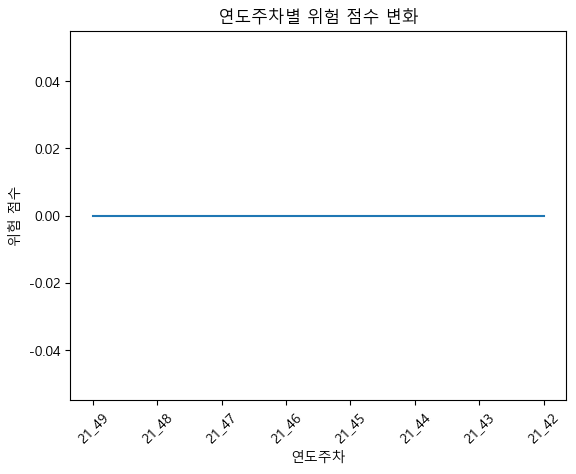

HS Code : 8708999000
         KOR_1  KOR_18     KOR_2       KOR_3  KOR_4  KOR_5  KOR_6  KOR_7  \
0   176219.674  22.144 19897.716  757442.376 24.874 23.804 23.932 21.040   
1   176454.419  22.213 20038.968  758508.890 24.938 23.915 23.795 20.332   
2   179603.742  22.655 20453.563  773293.021 25.346 24.272 24.264 20.891   
3   184012.793  23.273 21033.996  793990.805 25.916 24.772 24.919 21.674   
4   188421.845  23.892 21614.429  814688.589 26.487 25.272 25.575 22.458   
..         ...     ...       ...         ...    ...    ...    ...    ...   
292 301778.355  26.295 37153.516 1155595.203 30.423 33.799 19.898 21.937   
293 302764.441  26.423 37425.528 1161620.931 30.694 34.127 19.975 22.135   
294 304490.093  26.647 37901.548 1172165.954 31.169 34.701 20.111 22.481   
295 306215.744  26.871 38377.568 1182710.978 31.643 35.276 20.246 22.827   
296 307941.395  27.094 38853.588 1193256.001 32.118 35.850 20.382 23.173   

     KOR_8  KOR_9  ...      DJIA  NASDAQCOM   KOR_10  KOR_11  KOR_

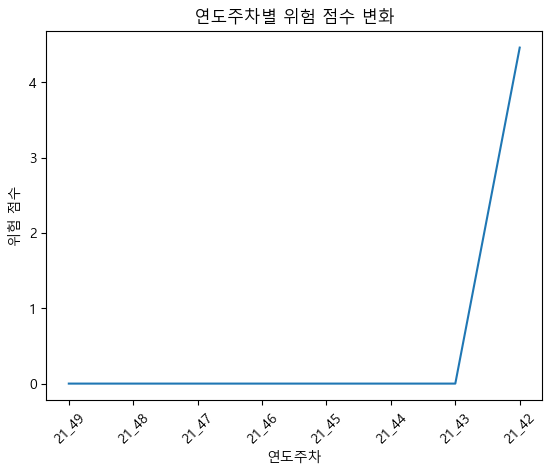

HS Code : 2106909099
         KOR_1  KOR_18     KOR_2       KOR_3  KOR_4  KOR_5  KOR_6  KOR_7  \
0   176219.674  22.144 19897.716  757442.376 24.874 23.804 23.932 21.040   
1   176454.419  22.213 20038.968  758508.890 24.938 23.915 23.795 20.332   
2   179603.742  22.655 20453.563  773293.021 25.346 24.272 24.264 20.891   
3   184012.793  23.273 21033.996  793990.805 25.916 24.772 24.919 21.674   
4   188421.845  23.892 21614.429  814688.589 26.487 25.272 25.575 22.458   
..         ...     ...       ...         ...    ...    ...    ...    ...   
292 301778.355  26.295 37153.516 1155595.203 30.423 33.799 19.898 21.937   
293 302764.441  26.423 37425.528 1161620.931 30.694 34.127 19.975 22.135   
294 304490.093  26.647 37901.548 1172165.954 31.169 34.701 20.111 22.481   
295 306215.744  26.871 38377.568 1182710.978 31.643 35.276 20.246 22.827   
296 307941.395  27.094 38853.588 1193256.001 32.118 35.850 20.382 23.173   

     KOR_8  KOR_9  ...      DJIA  NASDAQCOM   KOR_10  KOR_11  KOR_

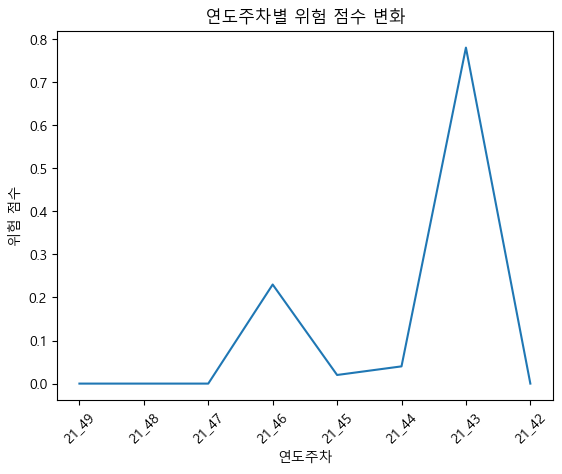

HS Code : 4911990000
         KOR_1  KOR_18     KOR_2       KOR_3  KOR_4  KOR_5  KOR_6  KOR_7  \
0   176219.674  22.144 19897.716  757442.376 24.874 23.804 23.932 21.040   
1   176454.419  22.213 20038.968  758508.890 24.938 23.915 23.795 20.332   
2   179603.742  22.655 20453.563  773293.021 25.346 24.272 24.264 20.891   
3   184012.793  23.273 21033.996  793990.805 25.916 24.772 24.919 21.674   
4   188421.845  23.892 21614.429  814688.589 26.487 25.272 25.575 22.458   
..         ...     ...       ...         ...    ...    ...    ...    ...   
292 301778.355  26.295 37153.516 1155595.203 30.423 33.799 19.898 21.937   
293 302764.441  26.423 37425.528 1161620.931 30.694 34.127 19.975 22.135   
294 304490.093  26.647 37901.548 1172165.954 31.169 34.701 20.111 22.481   
295 306215.744  26.871 38377.568 1182710.978 31.643 35.276 20.246 22.827   
296 307941.395  27.094 38853.588 1193256.001 32.118 35.850 20.382 23.173   

     KOR_8  KOR_9  ...      DJIA  NASDAQCOM   KOR_10  KOR_11  KOR_

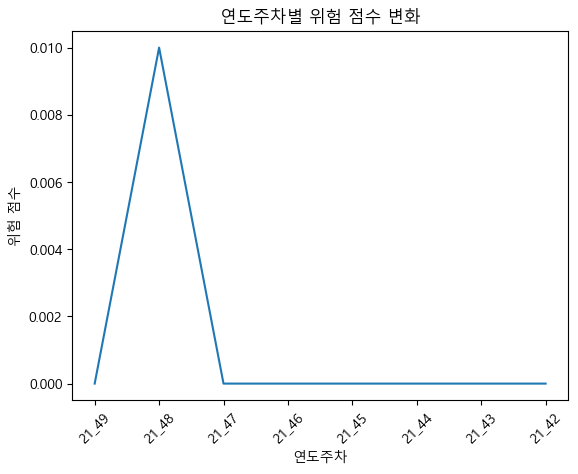

HS Code : 6403999000
         KOR_1  KOR_18     KOR_2       KOR_3  KOR_4  KOR_5  KOR_6  KOR_7  \
0   176219.674  22.144 19897.716  757442.376 24.874 23.804 23.932 21.040   
1   176454.419  22.213 20038.968  758508.890 24.938 23.915 23.795 20.332   
2   179603.742  22.655 20453.563  773293.021 25.346 24.272 24.264 20.891   
3   184012.793  23.273 21033.996  793990.805 25.916 24.772 24.919 21.674   
4   188421.845  23.892 21614.429  814688.589 26.487 25.272 25.575 22.458   
..         ...     ...       ...         ...    ...    ...    ...    ...   
292 301778.355  26.295 37153.516 1155595.203 30.423 33.799 19.898 21.937   
293 302764.441  26.423 37425.528 1161620.931 30.694 34.127 19.975 22.135   
294 304490.093  26.647 37901.548 1172165.954 31.169 34.701 20.111 22.481   
295 306215.744  26.871 38377.568 1182710.978 31.643 35.276 20.246 22.827   
296 307941.395  27.094 38853.588 1193256.001 32.118 35.850 20.382 23.173   

     KOR_8  KOR_9  ...      DJIA  NASDAQCOM   KOR_10  KOR_11  KOR_

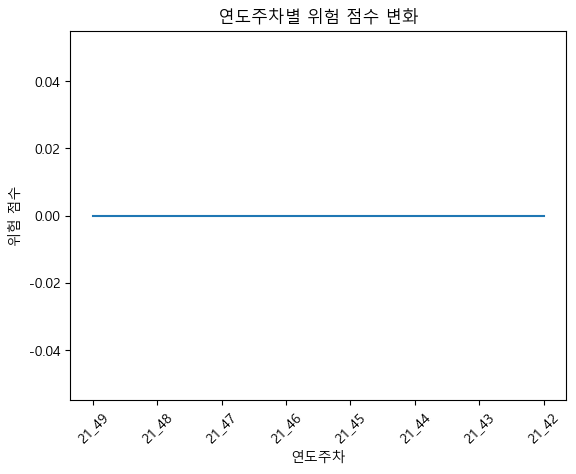

HS Code : 9031809099
         KOR_1  KOR_18     KOR_2       KOR_3  KOR_4  KOR_5  KOR_6  KOR_7  \
0   176219.674  22.144 19897.716  757442.376 24.874 23.804 23.932 21.040   
1   176454.419  22.213 20038.968  758508.890 24.938 23.915 23.795 20.332   
2   179603.742  22.655 20453.563  773293.021 25.346 24.272 24.264 20.891   
3   184012.793  23.273 21033.996  793990.805 25.916 24.772 24.919 21.674   
4   188421.845  23.892 21614.429  814688.589 26.487 25.272 25.575 22.458   
..         ...     ...       ...         ...    ...    ...    ...    ...   
292 301778.355  26.295 37153.516 1155595.203 30.423 33.799 19.898 21.937   
293 302764.441  26.423 37425.528 1161620.931 30.694 34.127 19.975 22.135   
294 304490.093  26.647 37901.548 1172165.954 31.169 34.701 20.111 22.481   
295 306215.744  26.871 38377.568 1182710.978 31.643 35.276 20.246 22.827   
296 307941.395  27.094 38853.588 1193256.001 32.118 35.850 20.382 23.173   

     KOR_8  KOR_9  ...      DJIA  NASDAQCOM   KOR_10  KOR_11  KOR_

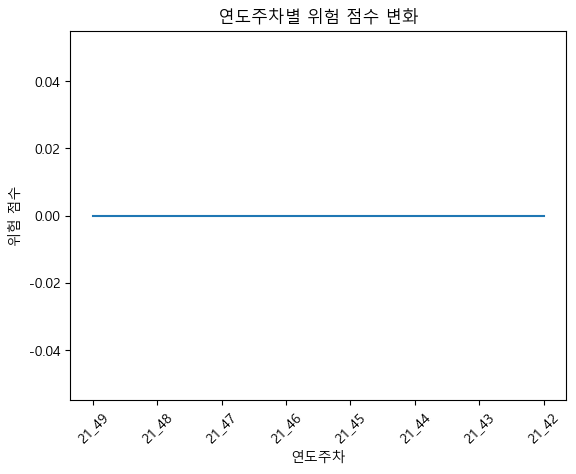

HS Code : 8542391000
         KOR_1  KOR_18     KOR_2       KOR_3  KOR_4  KOR_5  KOR_6  KOR_7  \
0   176219.674  22.144 19897.716  757442.376 24.874 23.804 23.932 21.040   
1   176454.419  22.213 20038.968  758508.890 24.938 23.915 23.795 20.332   
2   179603.742  22.655 20453.563  773293.021 25.346 24.272 24.264 20.891   
3   184012.793  23.273 21033.996  793990.805 25.916 24.772 24.919 21.674   
4   188421.845  23.892 21614.429  814688.589 26.487 25.272 25.575 22.458   
..         ...     ...       ...         ...    ...    ...    ...    ...   
292 301778.355  26.295 37153.516 1155595.203 30.423 33.799 19.898 21.937   
293 302764.441  26.423 37425.528 1161620.931 30.694 34.127 19.975 22.135   
294 304490.093  26.647 37901.548 1172165.954 31.169 34.701 20.111 22.481   
295 306215.744  26.871 38377.568 1182710.978 31.643 35.276 20.246 22.827   
296 307941.395  27.094 38853.588 1193256.001 32.118 35.850 20.382 23.173   

     KOR_8  KOR_9  ...      DJIA  NASDAQCOM   KOR_10  KOR_11  KOR_

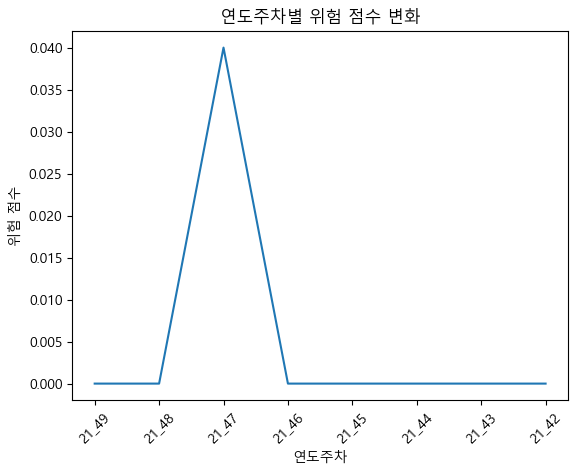

HS Code : 6109101000
         KOR_1  KOR_18     KOR_2       KOR_3  KOR_4  KOR_5  KOR_6  KOR_7  \
0   176219.674  22.144 19897.716  757442.376 24.874 23.804 23.932 21.040   
1   176454.419  22.213 20038.968  758508.890 24.938 23.915 23.795 20.332   
2   179603.742  22.655 20453.563  773293.021 25.346 24.272 24.264 20.891   
3   184012.793  23.273 21033.996  793990.805 25.916 24.772 24.919 21.674   
4   188421.845  23.892 21614.429  814688.589 26.487 25.272 25.575 22.458   
..         ...     ...       ...         ...    ...    ...    ...    ...   
292 301778.355  26.295 37153.516 1155595.203 30.423 33.799 19.898 21.937   
293 302764.441  26.423 37425.528 1161620.931 30.694 34.127 19.975 22.135   
294 304490.093  26.647 37901.548 1172165.954 31.169 34.701 20.111 22.481   
295 306215.744  26.871 38377.568 1182710.978 31.643 35.276 20.246 22.827   
296 307941.395  27.094 38853.588 1193256.001 32.118 35.850 20.382 23.173   

     KOR_8  KOR_9  ...      DJIA  NASDAQCOM   KOR_10  KOR_11  KOR_

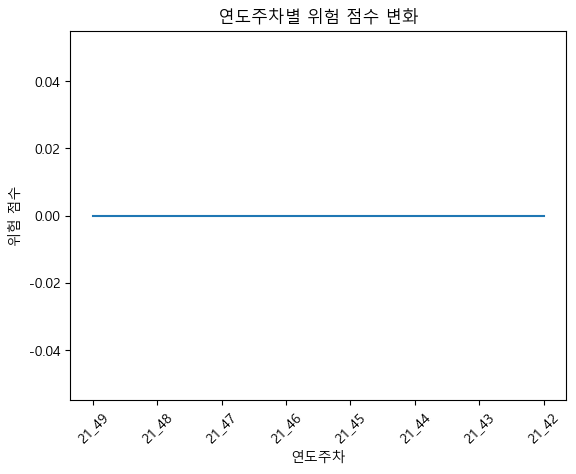

HS Code : 2934996000
         KOR_1  KOR_18     KOR_2       KOR_3  KOR_4  KOR_5  KOR_6  KOR_7  \
0   176219.674  22.144 19897.716  757442.376 24.874 23.804 23.932 21.040   
1   176454.419  22.213 20038.968  758508.890 24.938 23.915 23.795 20.332   
2   179603.742  22.655 20453.563  773293.021 25.346 24.272 24.264 20.891   
3   184012.793  23.273 21033.996  793990.805 25.916 24.772 24.919 21.674   
4   188421.845  23.892 21614.429  814688.589 26.487 25.272 25.575 22.458   
..         ...     ...       ...         ...    ...    ...    ...    ...   
292 301778.355  26.295 37153.516 1155595.203 30.423 33.799 19.898 21.937   
293 302764.441  26.423 37425.528 1161620.931 30.694 34.127 19.975 22.135   
294 304490.093  26.647 37901.548 1172165.954 31.169 34.701 20.111 22.481   
295 306215.744  26.871 38377.568 1182710.978 31.643 35.276 20.246 22.827   
296 307941.395  27.094 38853.588 1193256.001 32.118 35.850 20.382 23.173   

     KOR_8  KOR_9  ...      DJIA  NASDAQCOM   KOR_10  KOR_11  KOR_

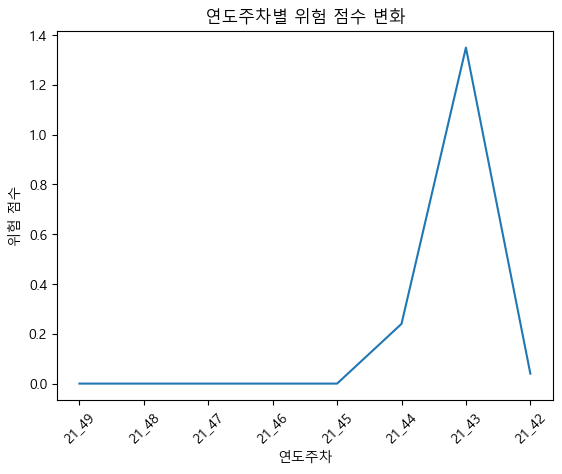

HS Code : 4016930000
         KOR_1  KOR_18     KOR_2       KOR_3  KOR_4  KOR_5  KOR_6  KOR_7  \
0   176219.674  22.144 19897.716  757442.376 24.874 23.804 23.932 21.040   
1   176454.419  22.213 20038.968  758508.890 24.938 23.915 23.795 20.332   
2   179603.742  22.655 20453.563  773293.021 25.346 24.272 24.264 20.891   
3   184012.793  23.273 21033.996  793990.805 25.916 24.772 24.919 21.674   
4   188421.845  23.892 21614.429  814688.589 26.487 25.272 25.575 22.458   
..         ...     ...       ...         ...    ...    ...    ...    ...   
292 301778.355  26.295 37153.516 1155595.203 30.423 33.799 19.898 21.937   
293 302764.441  26.423 37425.528 1161620.931 30.694 34.127 19.975 22.135   
294 304490.093  26.647 37901.548 1172165.954 31.169 34.701 20.111 22.481   
295 306215.744  26.871 38377.568 1182710.978 31.643 35.276 20.246 22.827   
296 307941.395  27.094 38853.588 1193256.001 32.118 35.850 20.382 23.173   

     KOR_8  KOR_9  ...      DJIA  NASDAQCOM   KOR_10  KOR_11  KOR_

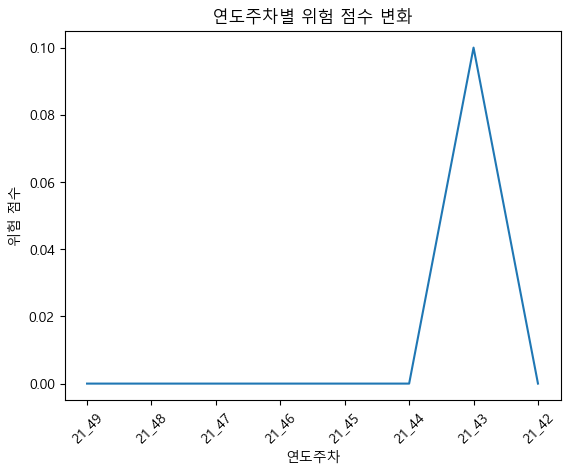

HS Code : 6110200000
         KOR_1  KOR_18     KOR_2       KOR_3  KOR_4  KOR_5  KOR_6  KOR_7  \
0   176219.674  22.144 19897.716  757442.376 24.874 23.804 23.932 21.040   
1   176454.419  22.213 20038.968  758508.890 24.938 23.915 23.795 20.332   
2   179603.742  22.655 20453.563  773293.021 25.346 24.272 24.264 20.891   
3   184012.793  23.273 21033.996  793990.805 25.916 24.772 24.919 21.674   
4   188421.845  23.892 21614.429  814688.589 26.487 25.272 25.575 22.458   
..         ...     ...       ...         ...    ...    ...    ...    ...   
292 301778.355  26.295 37153.516 1155595.203 30.423 33.799 19.898 21.937   
293 302764.441  26.423 37425.528 1161620.931 30.694 34.127 19.975 22.135   
294 304490.093  26.647 37901.548 1172165.954 31.169 34.701 20.111 22.481   
295 306215.744  26.871 38377.568 1182710.978 31.643 35.276 20.246 22.827   
296 307941.395  27.094 38853.588 1193256.001 32.118 35.850 20.382 23.173   

     KOR_8  KOR_9  ...      DJIA  NASDAQCOM   KOR_10  KOR_11  KOR_

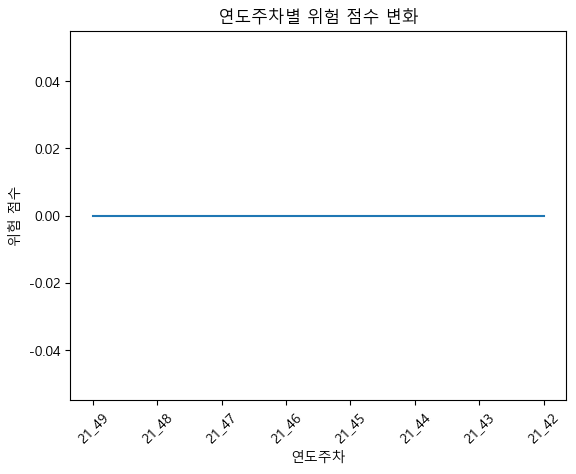

HS Code : 6211499000
         KOR_1  KOR_18     KOR_2       KOR_3  KOR_4  KOR_5  KOR_6  KOR_7  \
0   176219.674  22.144 19897.716  757442.376 24.874 23.804 23.932 21.040   
1   176454.419  22.213 20038.968  758508.890 24.938 23.915 23.795 20.332   
2   179603.742  22.655 20453.563  773293.021 25.346 24.272 24.264 20.891   
3   184012.793  23.273 21033.996  793990.805 25.916 24.772 24.919 21.674   
4   188421.845  23.892 21614.429  814688.589 26.487 25.272 25.575 22.458   
..         ...     ...       ...         ...    ...    ...    ...    ...   
292 301778.355  26.295 37153.516 1155595.203 30.423 33.799 19.898 21.937   
293 302764.441  26.423 37425.528 1161620.931 30.694 34.127 19.975 22.135   
294 304490.093  26.647 37901.548 1172165.954 31.169 34.701 20.111 22.481   
295 306215.744  26.871 38377.568 1182710.978 31.643 35.276 20.246 22.827   
296 307941.395  27.094 38853.588 1193256.001 32.118 35.850 20.382 23.173   

     KOR_8  KOR_9  ...      DJIA  NASDAQCOM   KOR_10  KOR_11  KOR_

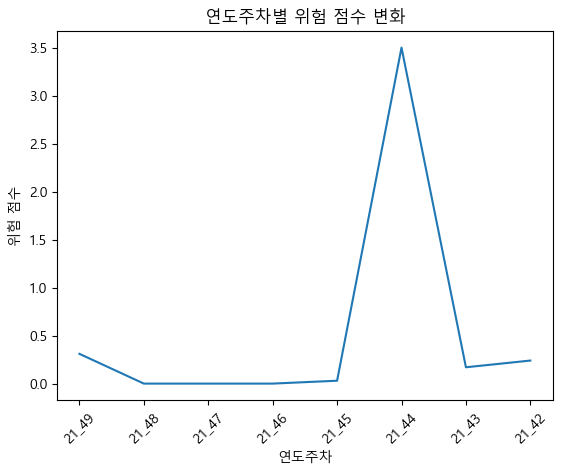

HS Code : 4202999000
         KOR_1  KOR_18     KOR_2       KOR_3  KOR_4  KOR_5  KOR_6  KOR_7  \
0   176219.674  22.144 19897.716  757442.376 24.874 23.804 23.932 21.040   
1   176454.419  22.213 20038.968  758508.890 24.938 23.915 23.795 20.332   
2   179603.742  22.655 20453.563  773293.021 25.346 24.272 24.264 20.891   
3   184012.793  23.273 21033.996  793990.805 25.916 24.772 24.919 21.674   
4   188421.845  23.892 21614.429  814688.589 26.487 25.272 25.575 22.458   
..         ...     ...       ...         ...    ...    ...    ...    ...   
292 301778.355  26.295 37153.516 1155595.203 30.423 33.799 19.898 21.937   
293 302764.441  26.423 37425.528 1161620.931 30.694 34.127 19.975 22.135   
294 304490.093  26.647 37901.548 1172165.954 31.169 34.701 20.111 22.481   
295 306215.744  26.871 38377.568 1182710.978 31.643 35.276 20.246 22.827   
296 307941.395  27.094 38853.588 1193256.001 32.118 35.850 20.382 23.173   

     KOR_8  KOR_9  ...      DJIA  NASDAQCOM   KOR_10  KOR_11  KOR_

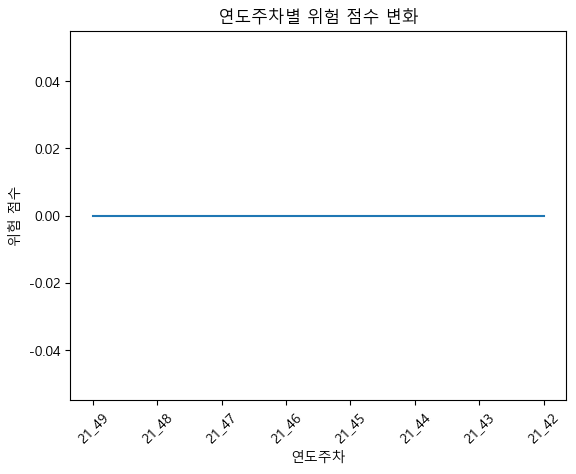

HS Code : 3304991000
         KOR_1  KOR_18     KOR_2       KOR_3  KOR_4  KOR_5  KOR_6  KOR_7  \
0   176219.674  22.144 19897.716  757442.376 24.874 23.804 23.932 21.040   
1   176454.419  22.213 20038.968  758508.890 24.938 23.915 23.795 20.332   
2   179603.742  22.655 20453.563  773293.021 25.346 24.272 24.264 20.891   
3   184012.793  23.273 21033.996  793990.805 25.916 24.772 24.919 21.674   
4   188421.845  23.892 21614.429  814688.589 26.487 25.272 25.575 22.458   
..         ...     ...       ...         ...    ...    ...    ...    ...   
292 301778.355  26.295 37153.516 1155595.203 30.423 33.799 19.898 21.937   
293 302764.441  26.423 37425.528 1161620.931 30.694 34.127 19.975 22.135   
294 304490.093  26.647 37901.548 1172165.954 31.169 34.701 20.111 22.481   
295 306215.744  26.871 38377.568 1182710.978 31.643 35.276 20.246 22.827   
296 307941.395  27.094 38853.588 1193256.001 32.118 35.850 20.382 23.173   

     KOR_8  KOR_9  ...      DJIA  NASDAQCOM   KOR_10  KOR_11  KOR_

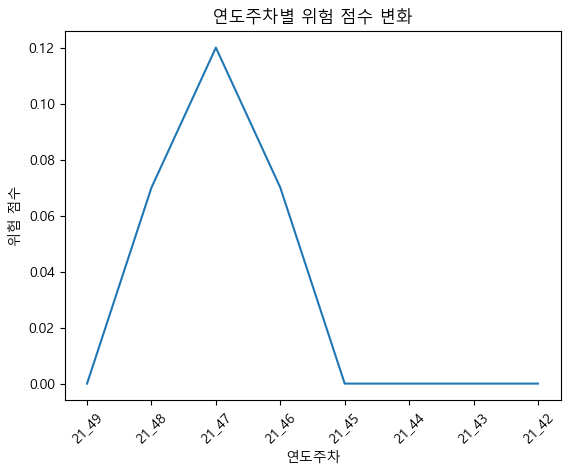

HS Code : 8544429090
         KOR_1  KOR_18     KOR_2       KOR_3  KOR_4  KOR_5  KOR_6  KOR_7  \
0   176219.674  22.144 19897.716  757442.376 24.874 23.804 23.932 21.040   
1   176454.419  22.213 20038.968  758508.890 24.938 23.915 23.795 20.332   
2   179603.742  22.655 20453.563  773293.021 25.346 24.272 24.264 20.891   
3   184012.793  23.273 21033.996  793990.805 25.916 24.772 24.919 21.674   
4   188421.845  23.892 21614.429  814688.589 26.487 25.272 25.575 22.458   
..         ...     ...       ...         ...    ...    ...    ...    ...   
292 301778.355  26.295 37153.516 1155595.203 30.423 33.799 19.898 21.937   
293 302764.441  26.423 37425.528 1161620.931 30.694 34.127 19.975 22.135   
294 304490.093  26.647 37901.548 1172165.954 31.169 34.701 20.111 22.481   
295 306215.744  26.871 38377.568 1182710.978 31.643 35.276 20.246 22.827   
296 307941.395  27.094 38853.588 1193256.001 32.118 35.850 20.382 23.173   

     KOR_8  KOR_9  ...      DJIA  NASDAQCOM   KOR_10  KOR_11  KOR_

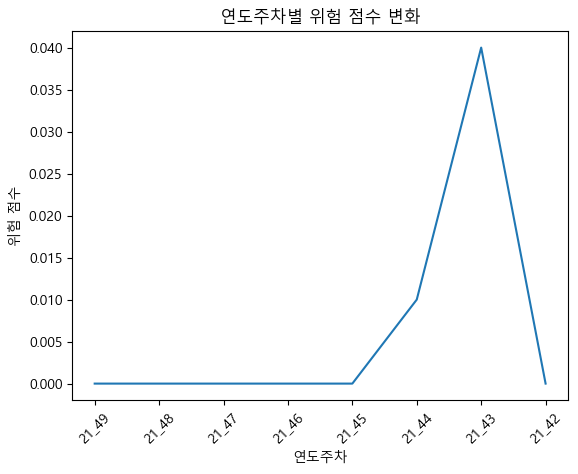

HS Code : 8481801090
         KOR_1  KOR_18     KOR_2       KOR_3  KOR_4  KOR_5  KOR_6  KOR_7  \
0   176219.674  22.144 19897.716  757442.376 24.874 23.804 23.932 21.040   
1   176454.419  22.213 20038.968  758508.890 24.938 23.915 23.795 20.332   
2   179603.742  22.655 20453.563  773293.021 25.346 24.272 24.264 20.891   
3   184012.793  23.273 21033.996  793990.805 25.916 24.772 24.919 21.674   
4   188421.845  23.892 21614.429  814688.589 26.487 25.272 25.575 22.458   
..         ...     ...       ...         ...    ...    ...    ...    ...   
292 301778.355  26.295 37153.516 1155595.203 30.423 33.799 19.898 21.937   
293 302764.441  26.423 37425.528 1161620.931 30.694 34.127 19.975 22.135   
294 304490.093  26.647 37901.548 1172165.954 31.169 34.701 20.111 22.481   
295 306215.744  26.871 38377.568 1182710.978 31.643 35.276 20.246 22.827   
296 307941.395  27.094 38853.588 1193256.001 32.118 35.850 20.382 23.173   

     KOR_8  KOR_9  ...      DJIA  NASDAQCOM   KOR_10  KOR_11  KOR_

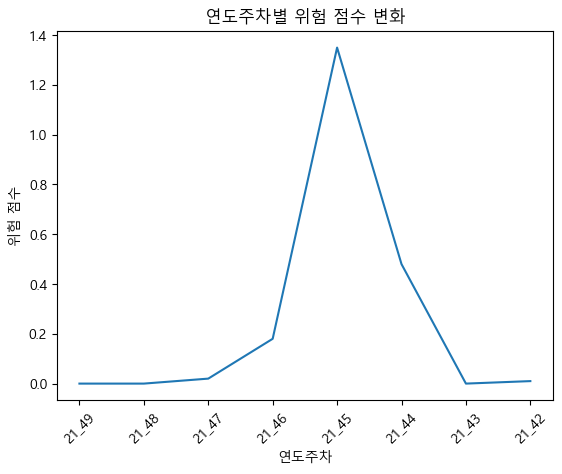

HS Code : 3304999000
         KOR_1  KOR_18     KOR_2       KOR_3  KOR_4  KOR_5  KOR_6  KOR_7  \
0   176219.674  22.144 19897.716  757442.376 24.874 23.804 23.932 21.040   
1   176454.419  22.213 20038.968  758508.890 24.938 23.915 23.795 20.332   
2   179603.742  22.655 20453.563  773293.021 25.346 24.272 24.264 20.891   
3   184012.793  23.273 21033.996  793990.805 25.916 24.772 24.919 21.674   
4   188421.845  23.892 21614.429  814688.589 26.487 25.272 25.575 22.458   
..         ...     ...       ...         ...    ...    ...    ...    ...   
292 301778.355  26.295 37153.516 1155595.203 30.423 33.799 19.898 21.937   
293 302764.441  26.423 37425.528 1161620.931 30.694 34.127 19.975 22.135   
294 304490.093  26.647 37901.548 1172165.954 31.169 34.701 20.111 22.481   
295 306215.744  26.871 38377.568 1182710.978 31.643 35.276 20.246 22.827   
296 307941.395  27.094 38853.588 1193256.001 32.118 35.850 20.382 23.173   

     KOR_8  KOR_9  ...      DJIA  NASDAQCOM   KOR_10  KOR_11  KOR_

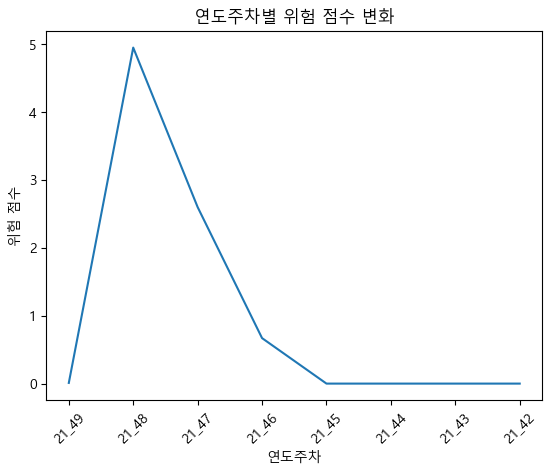

HS Code : 8543709090
         KOR_1  KOR_18     KOR_2       KOR_3  KOR_4  KOR_5  KOR_6  KOR_7  \
0   176219.674  22.144 19897.716  757442.376 24.874 23.804 23.932 21.040   
1   176454.419  22.213 20038.968  758508.890 24.938 23.915 23.795 20.332   
2   179603.742  22.655 20453.563  773293.021 25.346 24.272 24.264 20.891   
3   184012.793  23.273 21033.996  793990.805 25.916 24.772 24.919 21.674   
4   188421.845  23.892 21614.429  814688.589 26.487 25.272 25.575 22.458   
..         ...     ...       ...         ...    ...    ...    ...    ...   
292 301778.355  26.295 37153.516 1155595.203 30.423 33.799 19.898 21.937   
293 302764.441  26.423 37425.528 1161620.931 30.694 34.127 19.975 22.135   
294 304490.093  26.647 37901.548 1172165.954 31.169 34.701 20.111 22.481   
295 306215.744  26.871 38377.568 1182710.978 31.643 35.276 20.246 22.827   
296 307941.395  27.094 38853.588 1193256.001 32.118 35.850 20.382 23.173   

     KOR_8  KOR_9  ...      DJIA  NASDAQCOM   KOR_10  KOR_11  KOR_

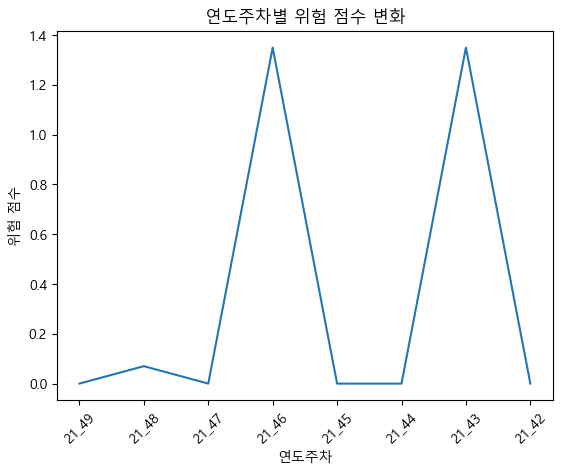

HS Code : 6404199000
         KOR_1  KOR_18     KOR_2       KOR_3  KOR_4  KOR_5  KOR_6  KOR_7  \
0   176219.674  22.144 19897.716  757442.376 24.874 23.804 23.932 21.040   
1   176454.419  22.213 20038.968  758508.890 24.938 23.915 23.795 20.332   
2   179603.742  22.655 20453.563  773293.021 25.346 24.272 24.264 20.891   
3   184012.793  23.273 21033.996  793990.805 25.916 24.772 24.919 21.674   
4   188421.845  23.892 21614.429  814688.589 26.487 25.272 25.575 22.458   
..         ...     ...       ...         ...    ...    ...    ...    ...   
292 301778.355  26.295 37153.516 1155595.203 30.423 33.799 19.898 21.937   
293 302764.441  26.423 37425.528 1161620.931 30.694 34.127 19.975 22.135   
294 304490.093  26.647 37901.548 1172165.954 31.169 34.701 20.111 22.481   
295 306215.744  26.871 38377.568 1182710.978 31.643 35.276 20.246 22.827   
296 307941.395  27.094 38853.588 1193256.001 32.118 35.850 20.382 23.173   

     KOR_8  KOR_9  ...      DJIA  NASDAQCOM   KOR_10  KOR_11  KOR_

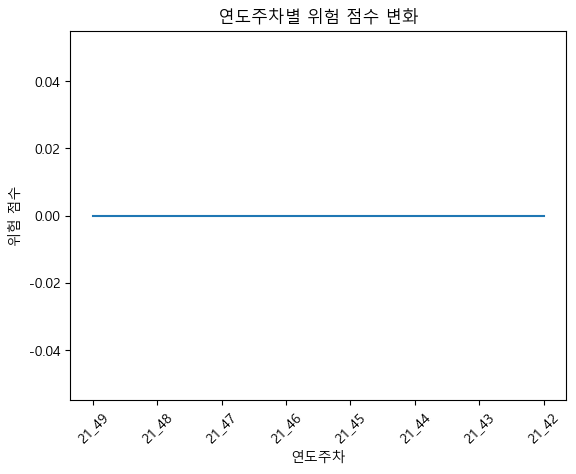

HS Code : 3004909900
         KOR_1  KOR_18     KOR_2       KOR_3  KOR_4  KOR_5  KOR_6  KOR_7  \
0   176219.674  22.144 19897.716  757442.376 24.874 23.804 23.932 21.040   
1   176454.419  22.213 20038.968  758508.890 24.938 23.915 23.795 20.332   
2   179603.742  22.655 20453.563  773293.021 25.346 24.272 24.264 20.891   
3   184012.793  23.273 21033.996  793990.805 25.916 24.772 24.919 21.674   
4   188421.845  23.892 21614.429  814688.589 26.487 25.272 25.575 22.458   
..         ...     ...       ...         ...    ...    ...    ...    ...   
292 301778.355  26.295 37153.516 1155595.203 30.423 33.799 19.898 21.937   
293 302764.441  26.423 37425.528 1161620.931 30.694 34.127 19.975 22.135   
294 304490.093  26.647 37901.548 1172165.954 31.169 34.701 20.111 22.481   
295 306215.744  26.871 38377.568 1182710.978 31.643 35.276 20.246 22.827   
296 307941.395  27.094 38853.588 1193256.001 32.118 35.850 20.382 23.173   

     KOR_8  KOR_9  ...      DJIA  NASDAQCOM   KOR_10  KOR_11  KOR_

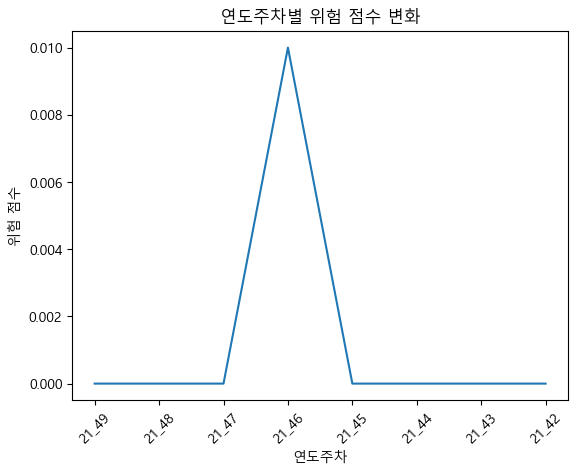

HS Code : 8542311000
         KOR_1  KOR_18     KOR_2       KOR_3  KOR_4  KOR_5  KOR_6  KOR_7  \
0   176219.674  22.144 19897.716  757442.376 24.874 23.804 23.932 21.040   
1   176454.419  22.213 20038.968  758508.890 24.938 23.915 23.795 20.332   
2   179603.742  22.655 20453.563  773293.021 25.346 24.272 24.264 20.891   
3   184012.793  23.273 21033.996  793990.805 25.916 24.772 24.919 21.674   
4   188421.845  23.892 21614.429  814688.589 26.487 25.272 25.575 22.458   
..         ...     ...       ...         ...    ...    ...    ...    ...   
292 301778.355  26.295 37153.516 1155595.203 30.423 33.799 19.898 21.937   
293 302764.441  26.423 37425.528 1161620.931 30.694 34.127 19.975 22.135   
294 304490.093  26.647 37901.548 1172165.954 31.169 34.701 20.111 22.481   
295 306215.744  26.871 38377.568 1182710.978 31.643 35.276 20.246 22.827   
296 307941.395  27.094 38853.588 1193256.001 32.118 35.850 20.382 23.173   

     KOR_8  KOR_9  ...      DJIA  NASDAQCOM   KOR_10  KOR_11  KOR_

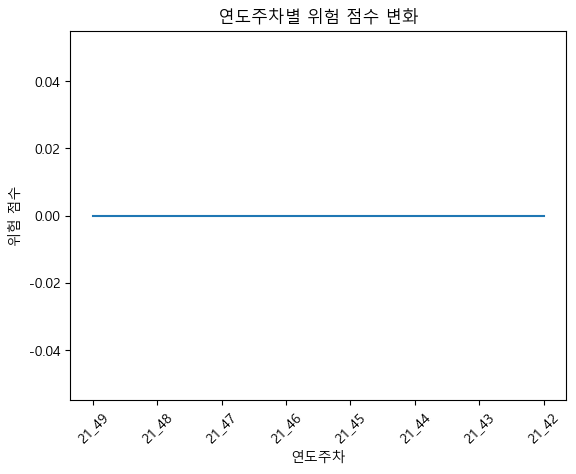

HS Code : 4901999000
         KOR_1  KOR_18     KOR_2       KOR_3  KOR_4  KOR_5  KOR_6  KOR_7  \
0   176219.674  22.144 19897.716  757442.376 24.874 23.804 23.932 21.040   
1   176454.419  22.213 20038.968  758508.890 24.938 23.915 23.795 20.332   
2   179603.742  22.655 20453.563  773293.021 25.346 24.272 24.264 20.891   
3   184012.793  23.273 21033.996  793990.805 25.916 24.772 24.919 21.674   
4   188421.845  23.892 21614.429  814688.589 26.487 25.272 25.575 22.458   
..         ...     ...       ...         ...    ...    ...    ...    ...   
292 301778.355  26.295 37153.516 1155595.203 30.423 33.799 19.898 21.937   
293 302764.441  26.423 37425.528 1161620.931 30.694 34.127 19.975 22.135   
294 304490.093  26.647 37901.548 1172165.954 31.169 34.701 20.111 22.481   
295 306215.744  26.871 38377.568 1182710.978 31.643 35.276 20.246 22.827   
296 307941.395  27.094 38853.588 1193256.001 32.118 35.850 20.382 23.173   

     KOR_8  KOR_9  ...      DJIA  NASDAQCOM   KOR_10  KOR_11  KOR_

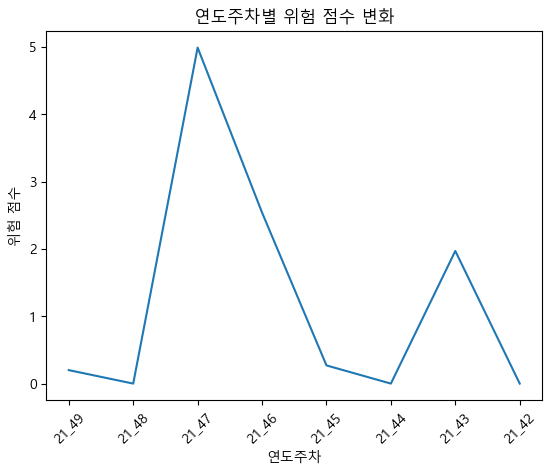

HS Code : 8473309090
         KOR_1  KOR_18     KOR_2       KOR_3  KOR_4  KOR_5  KOR_6  KOR_7  \
0   176219.674  22.144 19897.716  757442.376 24.874 23.804 23.932 21.040   
1   176454.419  22.213 20038.968  758508.890 24.938 23.915 23.795 20.332   
2   179603.742  22.655 20453.563  773293.021 25.346 24.272 24.264 20.891   
3   184012.793  23.273 21033.996  793990.805 25.916 24.772 24.919 21.674   
4   188421.845  23.892 21614.429  814688.589 26.487 25.272 25.575 22.458   
..         ...     ...       ...         ...    ...    ...    ...    ...   
292 301778.355  26.295 37153.516 1155595.203 30.423 33.799 19.898 21.937   
293 302764.441  26.423 37425.528 1161620.931 30.694 34.127 19.975 22.135   
294 304490.093  26.647 37901.548 1172165.954 31.169 34.701 20.111 22.481   
295 306215.744  26.871 38377.568 1182710.978 31.643 35.276 20.246 22.827   
296 307941.395  27.094 38853.588 1193256.001 32.118 35.850 20.382 23.173   

     KOR_8  KOR_9  ...      DJIA  NASDAQCOM   KOR_10  KOR_11  KOR_

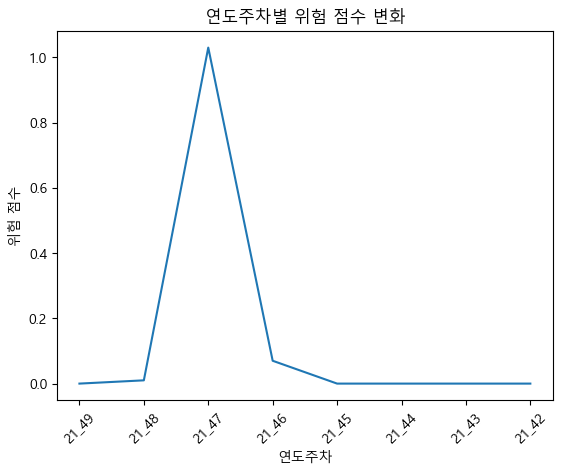

HS Code : 6307909000
         KOR_1  KOR_18     KOR_2       KOR_3  KOR_4  KOR_5  KOR_6  KOR_7  \
0   176219.674  22.144 19897.716  757442.376 24.874 23.804 23.932 21.040   
1   176454.419  22.213 20038.968  758508.890 24.938 23.915 23.795 20.332   
2   179603.742  22.655 20453.563  773293.021 25.346 24.272 24.264 20.891   
3   184012.793  23.273 21033.996  793990.805 25.916 24.772 24.919 21.674   
4   188421.845  23.892 21614.429  814688.589 26.487 25.272 25.575 22.458   
..         ...     ...       ...         ...    ...    ...    ...    ...   
292 301778.355  26.295 37153.516 1155595.203 30.423 33.799 19.898 21.937   
293 302764.441  26.423 37425.528 1161620.931 30.694 34.127 19.975 22.135   
294 304490.093  26.647 37901.548 1172165.954 31.169 34.701 20.111 22.481   
295 306215.744  26.871 38377.568 1182710.978 31.643 35.276 20.246 22.827   
296 307941.395  27.094 38853.588 1193256.001 32.118 35.850 20.382 23.173   

     KOR_8  KOR_9  ...      DJIA  NASDAQCOM   KOR_10  KOR_11  KOR_

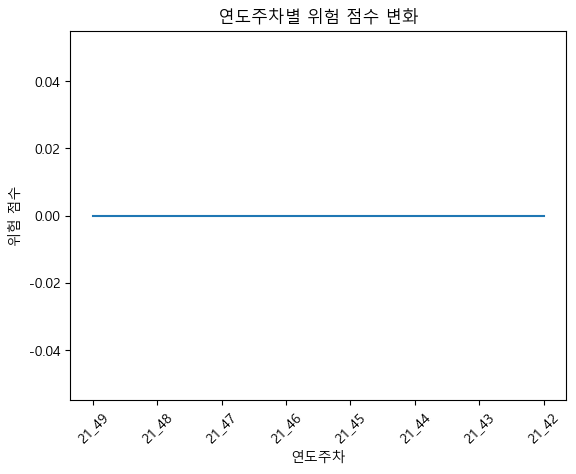

HS Code : 4202211090
         KOR_1  KOR_18     KOR_2       KOR_3  KOR_4  KOR_5  KOR_6  KOR_7  \
0   176219.674  22.144 19897.716  757442.376 24.874 23.804 23.932 21.040   
1   176454.419  22.213 20038.968  758508.890 24.938 23.915 23.795 20.332   
2   179603.742  22.655 20453.563  773293.021 25.346 24.272 24.264 20.891   
3   184012.793  23.273 21033.996  793990.805 25.916 24.772 24.919 21.674   
4   188421.845  23.892 21614.429  814688.589 26.487 25.272 25.575 22.458   
..         ...     ...       ...         ...    ...    ...    ...    ...   
292 301778.355  26.295 37153.516 1155595.203 30.423 33.799 19.898 21.937   
293 302764.441  26.423 37425.528 1161620.931 30.694 34.127 19.975 22.135   
294 304490.093  26.647 37901.548 1172165.954 31.169 34.701 20.111 22.481   
295 306215.744  26.871 38377.568 1182710.978 31.643 35.276 20.246 22.827   
296 307941.395  27.094 38853.588 1193256.001 32.118 35.850 20.382 23.173   

     KOR_8  KOR_9  ...      DJIA  NASDAQCOM   KOR_10  KOR_11  KOR_

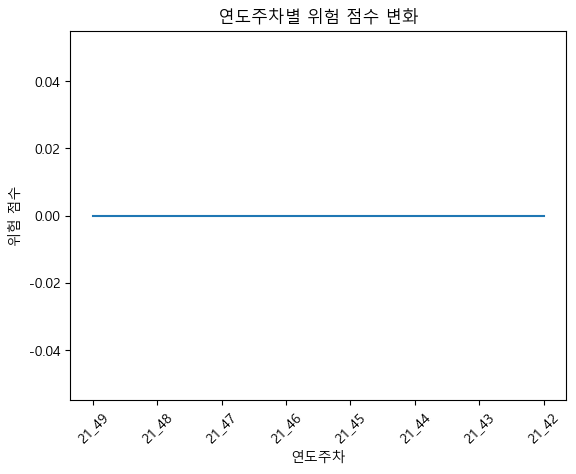

HS Code : 8536509090
         KOR_1  KOR_18     KOR_2       KOR_3  KOR_4  KOR_5  KOR_6  KOR_7  \
0   176219.674  22.144 19897.716  757442.376 24.874 23.804 23.932 21.040   
1   176454.419  22.213 20038.968  758508.890 24.938 23.915 23.795 20.332   
2   179603.742  22.655 20453.563  773293.021 25.346 24.272 24.264 20.891   
3   184012.793  23.273 21033.996  793990.805 25.916 24.772 24.919 21.674   
4   188421.845  23.892 21614.429  814688.589 26.487 25.272 25.575 22.458   
..         ...     ...       ...         ...    ...    ...    ...    ...   
292 301778.355  26.295 37153.516 1155595.203 30.423 33.799 19.898 21.937   
293 302764.441  26.423 37425.528 1161620.931 30.694 34.127 19.975 22.135   
294 304490.093  26.647 37901.548 1172165.954 31.169 34.701 20.111 22.481   
295 306215.744  26.871 38377.568 1182710.978 31.643 35.276 20.246 22.827   
296 307941.395  27.094 38853.588 1193256.001 32.118 35.850 20.382 23.173   

     KOR_8  KOR_9  ...      DJIA  NASDAQCOM   KOR_10  KOR_11  KOR_

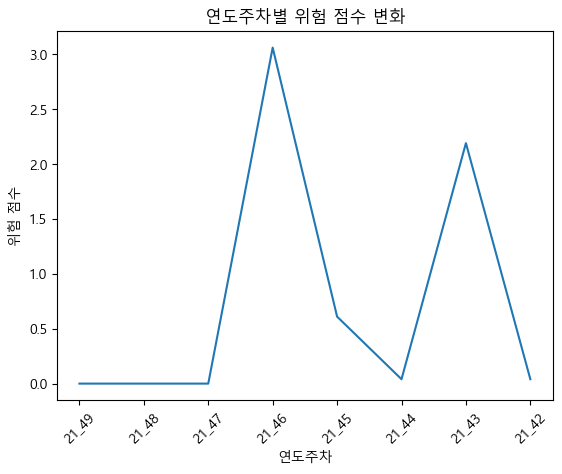

HS Code : 8538909000
         KOR_1  KOR_18     KOR_2       KOR_3  KOR_4  KOR_5  KOR_6  KOR_7  \
0   176219.674  22.144 19897.716  757442.376 24.874 23.804 23.932 21.040   
1   176454.419  22.213 20038.968  758508.890 24.938 23.915 23.795 20.332   
2   179603.742  22.655 20453.563  773293.021 25.346 24.272 24.264 20.891   
3   184012.793  23.273 21033.996  793990.805 25.916 24.772 24.919 21.674   
4   188421.845  23.892 21614.429  814688.589 26.487 25.272 25.575 22.458   
..         ...     ...       ...         ...    ...    ...    ...    ...   
292 301778.355  26.295 37153.516 1155595.203 30.423 33.799 19.898 21.937   
293 302764.441  26.423 37425.528 1161620.931 30.694 34.127 19.975 22.135   
294 304490.093  26.647 37901.548 1172165.954 31.169 34.701 20.111 22.481   
295 306215.744  26.871 38377.568 1182710.978 31.643 35.276 20.246 22.827   
296 307941.395  27.094 38853.588 1193256.001 32.118 35.850 20.382 23.173   

     KOR_8  KOR_9  ...      DJIA  NASDAQCOM   KOR_10  KOR_11  KOR_

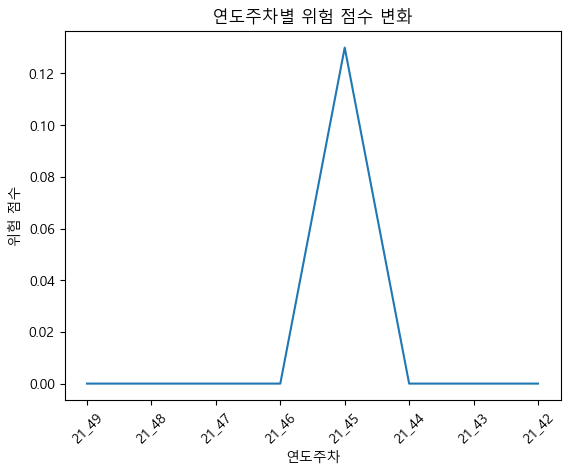

HS Code : 8479909090
         KOR_1  KOR_18     KOR_2       KOR_3  KOR_4  KOR_5  KOR_6  KOR_7  \
0   176219.674  22.144 19897.716  757442.376 24.874 23.804 23.932 21.040   
1   176454.419  22.213 20038.968  758508.890 24.938 23.915 23.795 20.332   
2   179603.742  22.655 20453.563  773293.021 25.346 24.272 24.264 20.891   
3   184012.793  23.273 21033.996  793990.805 25.916 24.772 24.919 21.674   
4   188421.845  23.892 21614.429  814688.589 26.487 25.272 25.575 22.458   
..         ...     ...       ...         ...    ...    ...    ...    ...   
292 301778.355  26.295 37153.516 1155595.203 30.423 33.799 19.898 21.937   
293 302764.441  26.423 37425.528 1161620.931 30.694 34.127 19.975 22.135   
294 304490.093  26.647 37901.548 1172165.954 31.169 34.701 20.111 22.481   
295 306215.744  26.871 38377.568 1182710.978 31.643 35.276 20.246 22.827   
296 307941.395  27.094 38853.588 1193256.001 32.118 35.850 20.382 23.173   

     KOR_8  KOR_9  ...      DJIA  NASDAQCOM   KOR_10  KOR_11  KOR_

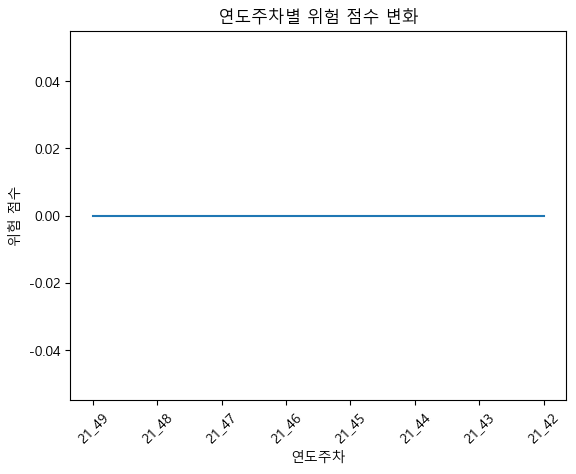

HS Code : 8504409099
         KOR_1  KOR_18     KOR_2       KOR_3  KOR_4  KOR_5  KOR_6  KOR_7  \
0   176219.674  22.144 19897.716  757442.376 24.874 23.804 23.932 21.040   
1   176454.419  22.213 20038.968  758508.890 24.938 23.915 23.795 20.332   
2   179603.742  22.655 20453.563  773293.021 25.346 24.272 24.264 20.891   
3   184012.793  23.273 21033.996  793990.805 25.916 24.772 24.919 21.674   
4   188421.845  23.892 21614.429  814688.589 26.487 25.272 25.575 22.458   
..         ...     ...       ...         ...    ...    ...    ...    ...   
292 301778.355  26.295 37153.516 1155595.203 30.423 33.799 19.898 21.937   
293 302764.441  26.423 37425.528 1161620.931 30.694 34.127 19.975 22.135   
294 304490.093  26.647 37901.548 1172165.954 31.169 34.701 20.111 22.481   
295 306215.744  26.871 38377.568 1182710.978 31.643 35.276 20.246 22.827   
296 307941.395  27.094 38853.588 1193256.001 32.118 35.850 20.382 23.173   

     KOR_8  KOR_9  ...      DJIA  NASDAQCOM   KOR_10  KOR_11  KOR_

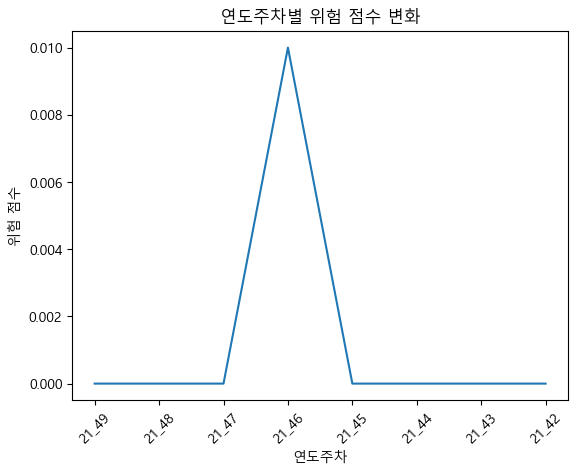

HS Code : 6110909000
         KOR_1  KOR_18     KOR_2       KOR_3  KOR_4  KOR_5  KOR_6  KOR_7  \
0   176219.674  22.144 19897.716  757442.376 24.874 23.804 23.932 21.040   
1   176454.419  22.213 20038.968  758508.890 24.938 23.915 23.795 20.332   
2   179603.742  22.655 20453.563  773293.021 25.346 24.272 24.264 20.891   
3   184012.793  23.273 21033.996  793990.805 25.916 24.772 24.919 21.674   
4   188421.845  23.892 21614.429  814688.589 26.487 25.272 25.575 22.458   
..         ...     ...       ...         ...    ...    ...    ...    ...   
292 301778.355  26.295 37153.516 1155595.203 30.423 33.799 19.898 21.937   
293 302764.441  26.423 37425.528 1161620.931 30.694 34.127 19.975 22.135   
294 304490.093  26.647 37901.548 1172165.954 31.169 34.701 20.111 22.481   
295 306215.744  26.871 38377.568 1182710.978 31.643 35.276 20.246 22.827   
296 307941.395  27.094 38853.588 1193256.001 32.118 35.850 20.382 23.173   

     KOR_8  KOR_9  ...      DJIA  NASDAQCOM   KOR_10  KOR_11  KOR_

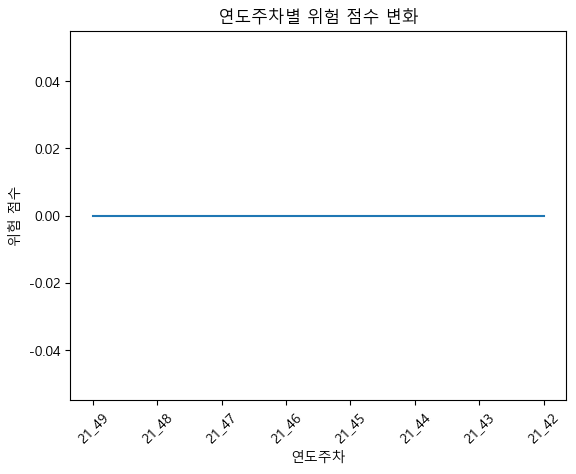

HS Code : 3923100000
         KOR_1  KOR_18     KOR_2       KOR_3  KOR_4  KOR_5  KOR_6  KOR_7  \
0   176219.674  22.144 19897.716  757442.376 24.874 23.804 23.932 21.040   
1   176454.419  22.213 20038.968  758508.890 24.938 23.915 23.795 20.332   
2   179603.742  22.655 20453.563  773293.021 25.346 24.272 24.264 20.891   
3   184012.793  23.273 21033.996  793990.805 25.916 24.772 24.919 21.674   
4   188421.845  23.892 21614.429  814688.589 26.487 25.272 25.575 22.458   
..         ...     ...       ...         ...    ...    ...    ...    ...   
292 301778.355  26.295 37153.516 1155595.203 30.423 33.799 19.898 21.937   
293 302764.441  26.423 37425.528 1161620.931 30.694 34.127 19.975 22.135   
294 304490.093  26.647 37901.548 1172165.954 31.169 34.701 20.111 22.481   
295 306215.744  26.871 38377.568 1182710.978 31.643 35.276 20.246 22.827   
296 307941.395  27.094 38853.588 1193256.001 32.118 35.850 20.382 23.173   

     KOR_8  KOR_9  ...      DJIA  NASDAQCOM   KOR_10  KOR_11  KOR_

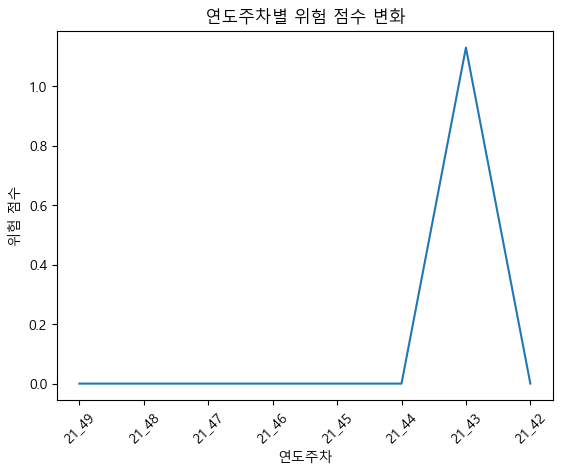

HS Code : 8544422090
         KOR_1  KOR_18     KOR_2       KOR_3  KOR_4  KOR_5  KOR_6  KOR_7  \
0   176219.674  22.144 19897.716  757442.376 24.874 23.804 23.932 21.040   
1   176454.419  22.213 20038.968  758508.890 24.938 23.915 23.795 20.332   
2   179603.742  22.655 20453.563  773293.021 25.346 24.272 24.264 20.891   
3   184012.793  23.273 21033.996  793990.805 25.916 24.772 24.919 21.674   
4   188421.845  23.892 21614.429  814688.589 26.487 25.272 25.575 22.458   
..         ...     ...       ...         ...    ...    ...    ...    ...   
292 301778.355  26.295 37153.516 1155595.203 30.423 33.799 19.898 21.937   
293 302764.441  26.423 37425.528 1161620.931 30.694 34.127 19.975 22.135   
294 304490.093  26.647 37901.548 1172165.954 31.169 34.701 20.111 22.481   
295 306215.744  26.871 38377.568 1182710.978 31.643 35.276 20.246 22.827   
296 307941.395  27.094 38853.588 1193256.001 32.118 35.850 20.382 23.173   

     KOR_8  KOR_9  ...      DJIA  NASDAQCOM   KOR_10  KOR_11  KOR_

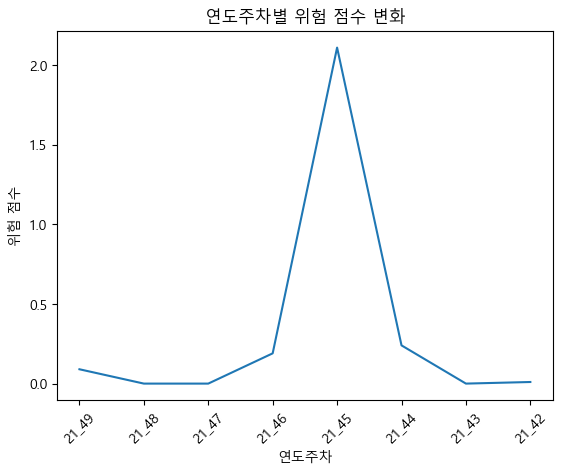

HS Code : 8537109000
         KOR_1  KOR_18     KOR_2       KOR_3  KOR_4  KOR_5  KOR_6  KOR_7  \
0   176219.674  22.144 19897.716  757442.376 24.874 23.804 23.932 21.040   
1   176454.419  22.213 20038.968  758508.890 24.938 23.915 23.795 20.332   
2   179603.742  22.655 20453.563  773293.021 25.346 24.272 24.264 20.891   
3   184012.793  23.273 21033.996  793990.805 25.916 24.772 24.919 21.674   
4   188421.845  23.892 21614.429  814688.589 26.487 25.272 25.575 22.458   
..         ...     ...       ...         ...    ...    ...    ...    ...   
292 301778.355  26.295 37153.516 1155595.203 30.423 33.799 19.898 21.937   
293 302764.441  26.423 37425.528 1161620.931 30.694 34.127 19.975 22.135   
294 304490.093  26.647 37901.548 1172165.954 31.169 34.701 20.111 22.481   
295 306215.744  26.871 38377.568 1182710.978 31.643 35.276 20.246 22.827   
296 307941.395  27.094 38853.588 1193256.001 32.118 35.850 20.382 23.173   

     KOR_8  KOR_9  ...      DJIA  NASDAQCOM   KOR_10  KOR_11  KOR_

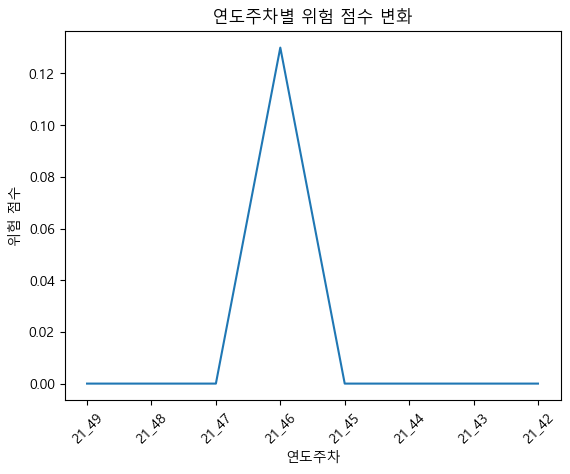

HS Code : 8536699000
         KOR_1  KOR_18     KOR_2       KOR_3  KOR_4  KOR_5  KOR_6  KOR_7  \
0   176219.674  22.144 19897.716  757442.376 24.874 23.804 23.932 21.040   
1   176454.419  22.213 20038.968  758508.890 24.938 23.915 23.795 20.332   
2   179603.742  22.655 20453.563  773293.021 25.346 24.272 24.264 20.891   
3   184012.793  23.273 21033.996  793990.805 25.916 24.772 24.919 21.674   
4   188421.845  23.892 21614.429  814688.589 26.487 25.272 25.575 22.458   
..         ...     ...       ...         ...    ...    ...    ...    ...   
292 301778.355  26.295 37153.516 1155595.203 30.423 33.799 19.898 21.937   
293 302764.441  26.423 37425.528 1161620.931 30.694 34.127 19.975 22.135   
294 304490.093  26.647 37901.548 1172165.954 31.169 34.701 20.111 22.481   
295 306215.744  26.871 38377.568 1182710.978 31.643 35.276 20.246 22.827   
296 307941.395  27.094 38853.588 1193256.001 32.118 35.850 20.382 23.173   

     KOR_8  KOR_9  ...      DJIA  NASDAQCOM   KOR_10  KOR_11  KOR_

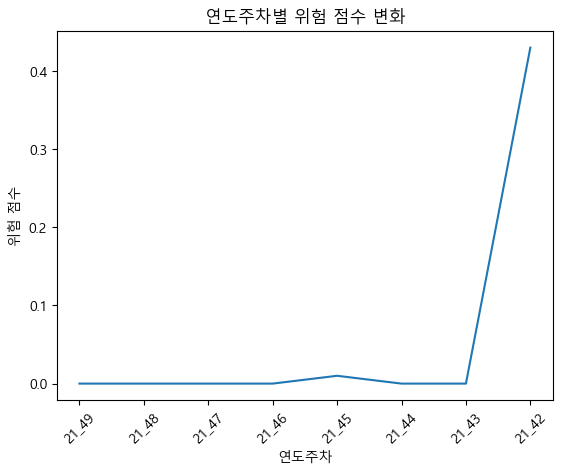

HS Code : 3102109000
         KOR_1  KOR_18     KOR_2       KOR_3  KOR_4  KOR_5  KOR_6  KOR_7  \
0   176219.674  22.144 19897.716  757442.376 24.874 23.804 23.932 21.040   
1   176454.419  22.213 20038.968  758508.890 24.938 23.915 23.795 20.332   
2   179603.742  22.655 20453.563  773293.021 25.346 24.272 24.264 20.891   
3   184012.793  23.273 21033.996  793990.805 25.916 24.772 24.919 21.674   
4   188421.845  23.892 21614.429  814688.589 26.487 25.272 25.575 22.458   
..         ...     ...       ...         ...    ...    ...    ...    ...   
292 301778.355  26.295 37153.516 1155595.203 30.423 33.799 19.898 21.937   
293 302764.441  26.423 37425.528 1161620.931 30.694 34.127 19.975 22.135   
294 304490.093  26.647 37901.548 1172165.954 31.169 34.701 20.111 22.481   
295 306215.744  26.871 38377.568 1182710.978 31.643 35.276 20.246 22.827   
296 307941.395  27.094 38853.588 1193256.001 32.118 35.850 20.382 23.173   

     KOR_8  KOR_9  ...      DJIA  NASDAQCOM   KOR_10  KOR_11  KOR_

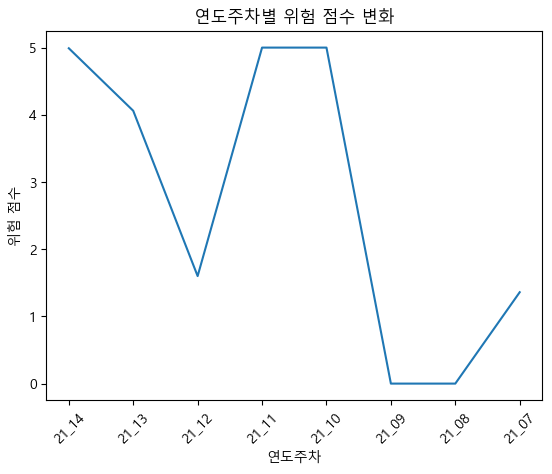

HS Code : 3707901010
         KOR_1  KOR_18     KOR_2       KOR_3  KOR_4  KOR_5  KOR_6  KOR_7  \
0   176219.674  22.144 19897.716  757442.376 24.874 23.804 23.932 21.040   
1   176454.419  22.213 20038.968  758508.890 24.938 23.915 23.795 20.332   
2   179603.742  22.655 20453.563  773293.021 25.346 24.272 24.264 20.891   
3   184012.793  23.273 21033.996  793990.805 25.916 24.772 24.919 21.674   
4   188421.845  23.892 21614.429  814688.589 26.487 25.272 25.575 22.458   
..         ...     ...       ...         ...    ...    ...    ...    ...   
292 301778.355  26.295 37153.516 1155595.203 30.423 33.799 19.898 21.937   
293 302764.441  26.423 37425.528 1161620.931 30.694 34.127 19.975 22.135   
294 304490.093  26.647 37901.548 1172165.954 31.169 34.701 20.111 22.481   
295 306215.744  26.871 38377.568 1182710.978 31.643 35.276 20.246 22.827   
296 307941.395  27.094 38853.588 1193256.001 32.118 35.850 20.382 23.173   

     KOR_8  KOR_9  ...      DJIA  NASDAQCOM   KOR_10  KOR_11  KOR_

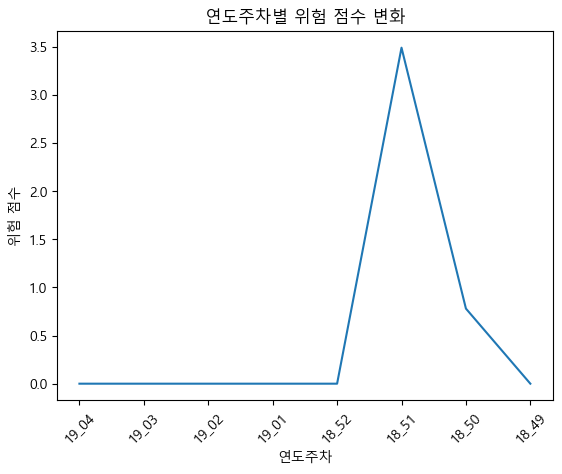

HS Code : 4407191000
         KOR_1  KOR_18     KOR_2       KOR_3  KOR_4  KOR_5  KOR_6  KOR_7  \
0   176219.674  22.144 19897.716  757442.376 24.874 23.804 23.932 21.040   
1   176454.419  22.213 20038.968  758508.890 24.938 23.915 23.795 20.332   
2   179603.742  22.655 20453.563  773293.021 25.346 24.272 24.264 20.891   
3   184012.793  23.273 21033.996  793990.805 25.916 24.772 24.919 21.674   
4   188421.845  23.892 21614.429  814688.589 26.487 25.272 25.575 22.458   
..         ...     ...       ...         ...    ...    ...    ...    ...   
292 301778.355  26.295 37153.516 1155595.203 30.423 33.799 19.898 21.937   
293 302764.441  26.423 37425.528 1161620.931 30.694 34.127 19.975 22.135   
294 304490.093  26.647 37901.548 1172165.954 31.169 34.701 20.111 22.481   
295 306215.744  26.871 38377.568 1182710.978 31.643 35.276 20.246 22.827   
296 307941.395  27.094 38853.588 1193256.001 32.118 35.850 20.382 23.173   

     KOR_8  KOR_9  ...      DJIA  NASDAQCOM   KOR_10  KOR_11  KOR_

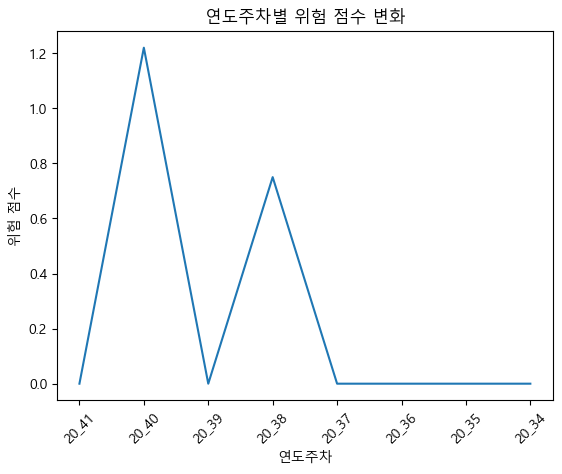

HS Code : 8111000000
         KOR_1  KOR_18     KOR_2       KOR_3  KOR_4  KOR_5  KOR_6  KOR_7  \
0   176219.674  22.144 19897.716  757442.376 24.874 23.804 23.932 21.040   
1   176454.419  22.213 20038.968  758508.890 24.938 23.915 23.795 20.332   
2   179603.742  22.655 20453.563  773293.021 25.346 24.272 24.264 20.891   
3   184012.793  23.273 21033.996  793990.805 25.916 24.772 24.919 21.674   
4   188421.845  23.892 21614.429  814688.589 26.487 25.272 25.575 22.458   
..         ...     ...       ...         ...    ...    ...    ...    ...   
292 301778.355  26.295 37153.516 1155595.203 30.423 33.799 19.898 21.937   
293 302764.441  26.423 37425.528 1161620.931 30.694 34.127 19.975 22.135   
294 304490.093  26.647 37901.548 1172165.954 31.169 34.701 20.111 22.481   
295 306215.744  26.871 38377.568 1182710.978 31.643 35.276 20.246 22.827   
296 307941.395  27.094 38853.588 1193256.001 32.118 35.850 20.382 23.173   

     KOR_8  KOR_9  ...      DJIA  NASDAQCOM   KOR_10  KOR_11  KOR_

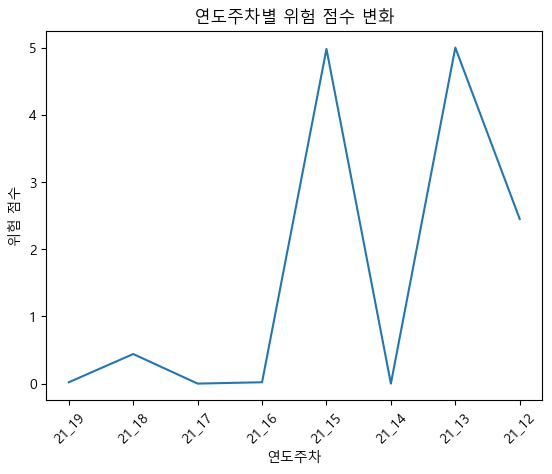

HS Code : 2701129010
         KOR_1  KOR_18     KOR_2       KOR_3  KOR_4  KOR_5  KOR_6  KOR_7  \
0   176219.674  22.144 19897.716  757442.376 24.874 23.804 23.932 21.040   
1   176454.419  22.213 20038.968  758508.890 24.938 23.915 23.795 20.332   
2   179603.742  22.655 20453.563  773293.021 25.346 24.272 24.264 20.891   
3   184012.793  23.273 21033.996  793990.805 25.916 24.772 24.919 21.674   
4   188421.845  23.892 21614.429  814688.589 26.487 25.272 25.575 22.458   
..         ...     ...       ...         ...    ...    ...    ...    ...   
292 301778.355  26.295 37153.516 1155595.203 30.423 33.799 19.898 21.937   
293 302764.441  26.423 37425.528 1161620.931 30.694 34.127 19.975 22.135   
294 304490.093  26.647 37901.548 1172165.954 31.169 34.701 20.111 22.481   
295 306215.744  26.871 38377.568 1182710.978 31.643 35.276 20.246 22.827   
296 307941.395  27.094 38853.588 1193256.001 32.118 35.850 20.382 23.173   

     KOR_8  KOR_9  ...      DJIA  NASDAQCOM   KOR_10  KOR_11  KOR_

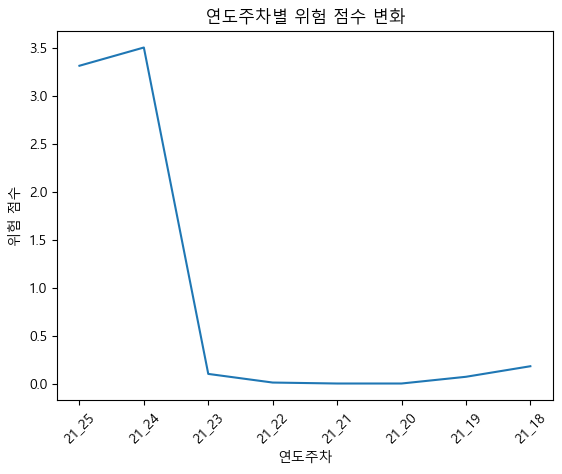

HS Code : 2804701000
         KOR_1  KOR_18     KOR_2       KOR_3  KOR_4  KOR_5  KOR_6  KOR_7  \
0   176219.674  22.144 19897.716  757442.376 24.874 23.804 23.932 21.040   
1   176454.419  22.213 20038.968  758508.890 24.938 23.915 23.795 20.332   
2   179603.742  22.655 20453.563  773293.021 25.346 24.272 24.264 20.891   
3   184012.793  23.273 21033.996  793990.805 25.916 24.772 24.919 21.674   
4   188421.845  23.892 21614.429  814688.589 26.487 25.272 25.575 22.458   
..         ...     ...       ...         ...    ...    ...    ...    ...   
292 301778.355  26.295 37153.516 1155595.203 30.423 33.799 19.898 21.937   
293 302764.441  26.423 37425.528 1161620.931 30.694 34.127 19.975 22.135   
294 304490.093  26.647 37901.548 1172165.954 31.169 34.701 20.111 22.481   
295 306215.744  26.871 38377.568 1182710.978 31.643 35.276 20.246 22.827   
296 307941.395  27.094 38853.588 1193256.001 32.118 35.850 20.382 23.173   

     KOR_8  KOR_9  ...      DJIA  NASDAQCOM   KOR_10  KOR_11  KOR_

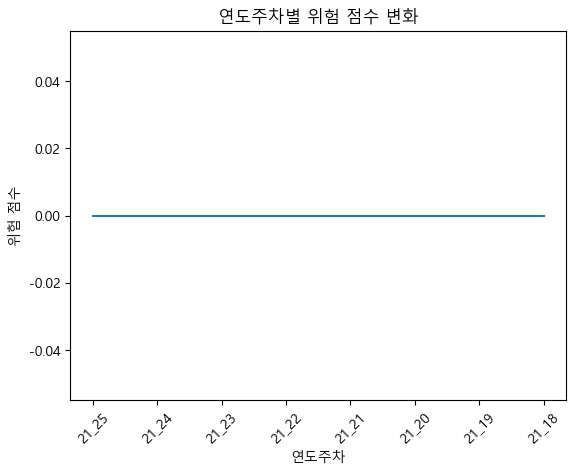

HS Code : 1511901000
         KOR_1  KOR_18     KOR_2       KOR_3  KOR_4  KOR_5  KOR_6  KOR_7  \
0   176219.674  22.144 19897.716  757442.376 24.874 23.804 23.932 21.040   
1   176454.419  22.213 20038.968  758508.890 24.938 23.915 23.795 20.332   
2   179603.742  22.655 20453.563  773293.021 25.346 24.272 24.264 20.891   
3   184012.793  23.273 21033.996  793990.805 25.916 24.772 24.919 21.674   
4   188421.845  23.892 21614.429  814688.589 26.487 25.272 25.575 22.458   
..         ...     ...       ...         ...    ...    ...    ...    ...   
292 301778.355  26.295 37153.516 1155595.203 30.423 33.799 19.898 21.937   
293 302764.441  26.423 37425.528 1161620.931 30.694 34.127 19.975 22.135   
294 304490.093  26.647 37901.548 1172165.954 31.169 34.701 20.111 22.481   
295 306215.744  26.871 38377.568 1182710.978 31.643 35.276 20.246 22.827   
296 307941.395  27.094 38853.588 1193256.001 32.118 35.850 20.382 23.173   

     KOR_8  KOR_9  ...      DJIA  NASDAQCOM   KOR_10  KOR_11  KOR_

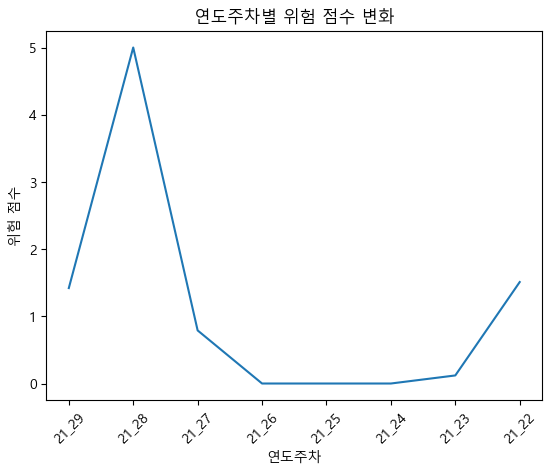

HS Code : 305531000
         KOR_1  KOR_18     KOR_2       KOR_3  KOR_4  KOR_5  KOR_6  KOR_7  \
0   176219.674  22.144 19897.716  757442.376 24.874 23.804 23.932 21.040   
1   176454.419  22.213 20038.968  758508.890 24.938 23.915 23.795 20.332   
2   179603.742  22.655 20453.563  773293.021 25.346 24.272 24.264 20.891   
3   184012.793  23.273 21033.996  793990.805 25.916 24.772 24.919 21.674   
4   188421.845  23.892 21614.429  814688.589 26.487 25.272 25.575 22.458   
..         ...     ...       ...         ...    ...    ...    ...    ...   
292 301778.355  26.295 37153.516 1155595.203 30.423 33.799 19.898 21.937   
293 302764.441  26.423 37425.528 1161620.931 30.694 34.127 19.975 22.135   
294 304490.093  26.647 37901.548 1172165.954 31.169 34.701 20.111 22.481   
295 306215.744  26.871 38377.568 1182710.978 31.643 35.276 20.246 22.827   
296 307941.395  27.094 38853.588 1193256.001 32.118 35.850 20.382 23.173   

     KOR_8  KOR_9  ...      DJIA  NASDAQCOM   KOR_10  KOR_11  KOR_1

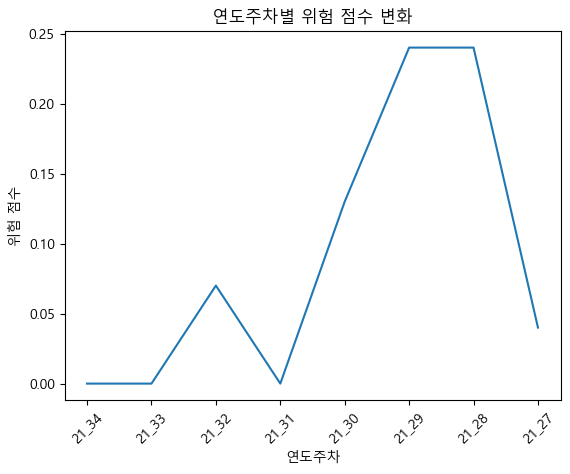

HS Code : 302140000
         KOR_1  KOR_18     KOR_2       KOR_3  KOR_4  KOR_5  KOR_6  KOR_7  \
0   176219.674  22.144 19897.716  757442.376 24.874 23.804 23.932 21.040   
1   176454.419  22.213 20038.968  758508.890 24.938 23.915 23.795 20.332   
2   179603.742  22.655 20453.563  773293.021 25.346 24.272 24.264 20.891   
3   184012.793  23.273 21033.996  793990.805 25.916 24.772 24.919 21.674   
4   188421.845  23.892 21614.429  814688.589 26.487 25.272 25.575 22.458   
..         ...     ...       ...         ...    ...    ...    ...    ...   
292 301778.355  26.295 37153.516 1155595.203 30.423 33.799 19.898 21.937   
293 302764.441  26.423 37425.528 1161620.931 30.694 34.127 19.975 22.135   
294 304490.093  26.647 37901.548 1172165.954 31.169 34.701 20.111 22.481   
295 306215.744  26.871 38377.568 1182710.978 31.643 35.276 20.246 22.827   
296 307941.395  27.094 38853.588 1193256.001 32.118 35.850 20.382 23.173   

     KOR_8  KOR_9  ...      DJIA  NASDAQCOM   KOR_10  KOR_11  KOR_1

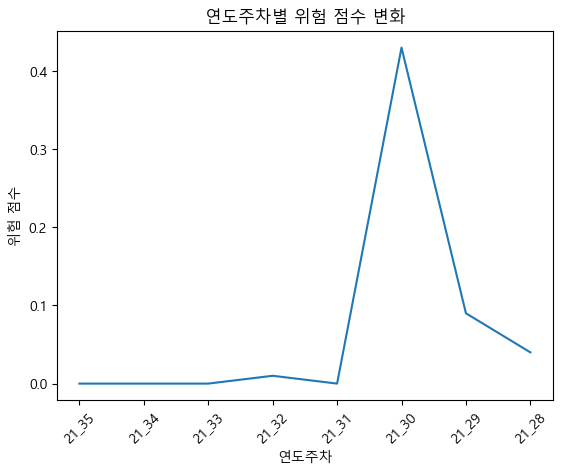

HS Code : 1003901000
         KOR_1  KOR_18     KOR_2       KOR_3  KOR_4  KOR_5  KOR_6  KOR_7  \
0   176219.674  22.144 19897.716  757442.376 24.874 23.804 23.932 21.040   
1   176454.419  22.213 20038.968  758508.890 24.938 23.915 23.795 20.332   
2   179603.742  22.655 20453.563  773293.021 25.346 24.272 24.264 20.891   
3   184012.793  23.273 21033.996  793990.805 25.916 24.772 24.919 21.674   
4   188421.845  23.892 21614.429  814688.589 26.487 25.272 25.575 22.458   
..         ...     ...       ...         ...    ...    ...    ...    ...   
292 301778.355  26.295 37153.516 1155595.203 30.423 33.799 19.898 21.937   
293 302764.441  26.423 37425.528 1161620.931 30.694 34.127 19.975 22.135   
294 304490.093  26.647 37901.548 1172165.954 31.169 34.701 20.111 22.481   
295 306215.744  26.871 38377.568 1182710.978 31.643 35.276 20.246 22.827   
296 307941.395  27.094 38853.588 1193256.001 32.118 35.850 20.382 23.173   

     KOR_8  KOR_9  ...      DJIA  NASDAQCOM   KOR_10  KOR_11  KOR_

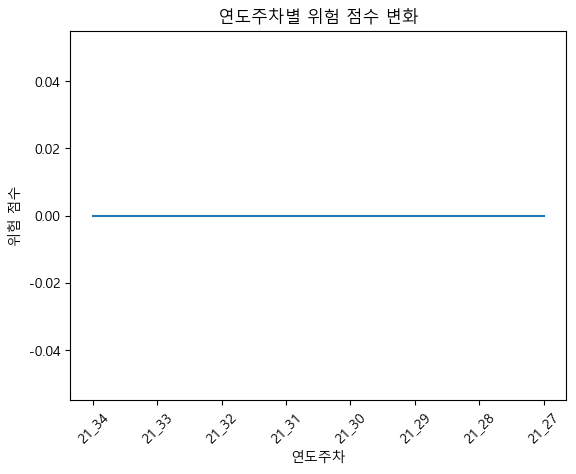

HS Code : 1003902000
         KOR_1  KOR_18     KOR_2       KOR_3  KOR_4  KOR_5  KOR_6  KOR_7  \
0   176219.674  22.144 19897.716  757442.376 24.874 23.804 23.932 21.040   
1   176454.419  22.213 20038.968  758508.890 24.938 23.915 23.795 20.332   
2   179603.742  22.655 20453.563  773293.021 25.346 24.272 24.264 20.891   
3   184012.793  23.273 21033.996  793990.805 25.916 24.772 24.919 21.674   
4   188421.845  23.892 21614.429  814688.589 26.487 25.272 25.575 22.458   
..         ...     ...       ...         ...    ...    ...    ...    ...   
292 301778.355  26.295 37153.516 1155595.203 30.423 33.799 19.898 21.937   
293 302764.441  26.423 37425.528 1161620.931 30.694 34.127 19.975 22.135   
294 304490.093  26.647 37901.548 1172165.954 31.169 34.701 20.111 22.481   
295 306215.744  26.871 38377.568 1182710.978 31.643 35.276 20.246 22.827   
296 307941.395  27.094 38853.588 1193256.001 32.118 35.850 20.382 23.173   

     KOR_8  KOR_9  ...      DJIA  NASDAQCOM   KOR_10  KOR_11  KOR_

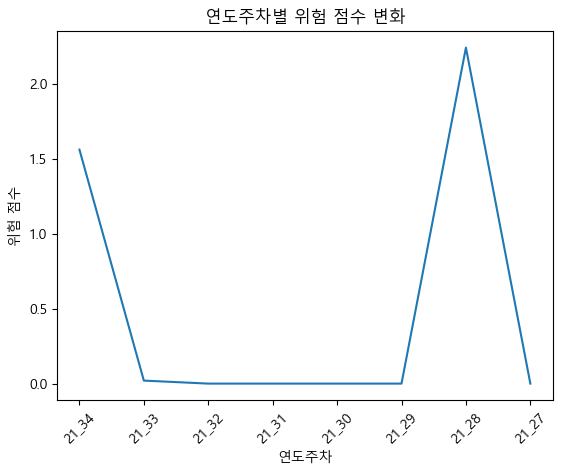

HS Code : 1104230000
         KOR_1  KOR_18     KOR_2       KOR_3  KOR_4  KOR_5  KOR_6  KOR_7  \
0   176219.674  22.144 19897.716  757442.376 24.874 23.804 23.932 21.040   
1   176454.419  22.213 20038.968  758508.890 24.938 23.915 23.795 20.332   
2   179603.742  22.655 20453.563  773293.021 25.346 24.272 24.264 20.891   
3   184012.793  23.273 21033.996  793990.805 25.916 24.772 24.919 21.674   
4   188421.845  23.892 21614.429  814688.589 26.487 25.272 25.575 22.458   
..         ...     ...       ...         ...    ...    ...    ...    ...   
292 301778.355  26.295 37153.516 1155595.203 30.423 33.799 19.898 21.937   
293 302764.441  26.423 37425.528 1161620.931 30.694 34.127 19.975 22.135   
294 304490.093  26.647 37901.548 1172165.954 31.169 34.701 20.111 22.481   
295 306215.744  26.871 38377.568 1182710.978 31.643 35.276 20.246 22.827   
296 307941.395  27.094 38853.588 1193256.001 32.118 35.850 20.382 23.173   

     KOR_8  KOR_9  ...      DJIA  NASDAQCOM   KOR_10  KOR_11  KOR_

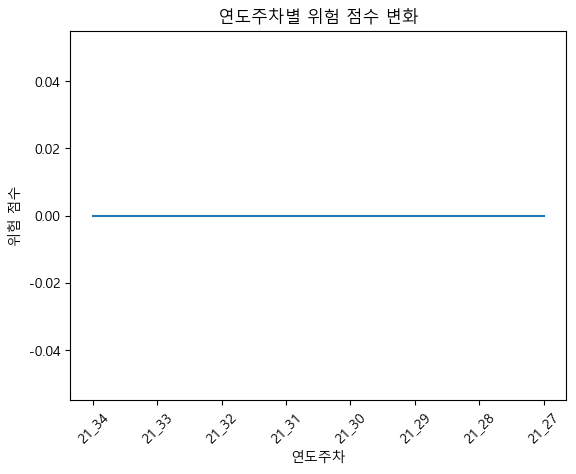

HS Code : 2710121000
         KOR_1  KOR_18     KOR_2       KOR_3  KOR_4  KOR_5  KOR_6  KOR_7  \
0   176219.674  22.144 19897.716  757442.376 24.874 23.804 23.932 21.040   
1   176454.419  22.213 20038.968  758508.890 24.938 23.915 23.795 20.332   
2   179603.742  22.655 20453.563  773293.021 25.346 24.272 24.264 20.891   
3   184012.793  23.273 21033.996  793990.805 25.916 24.772 24.919 21.674   
4   188421.845  23.892 21614.429  814688.589 26.487 25.272 25.575 22.458   
..         ...     ...       ...         ...    ...    ...    ...    ...   
292 301778.355  26.295 37153.516 1155595.203 30.423 33.799 19.898 21.937   
293 302764.441  26.423 37425.528 1161620.931 30.694 34.127 19.975 22.135   
294 304490.093  26.647 37901.548 1172165.954 31.169 34.701 20.111 22.481   
295 306215.744  26.871 38377.568 1182710.978 31.643 35.276 20.246 22.827   
296 307941.395  27.094 38853.588 1193256.001 32.118 35.850 20.382 23.173   

     KOR_8  KOR_9  ...      DJIA  NASDAQCOM   KOR_10  KOR_11  KOR_

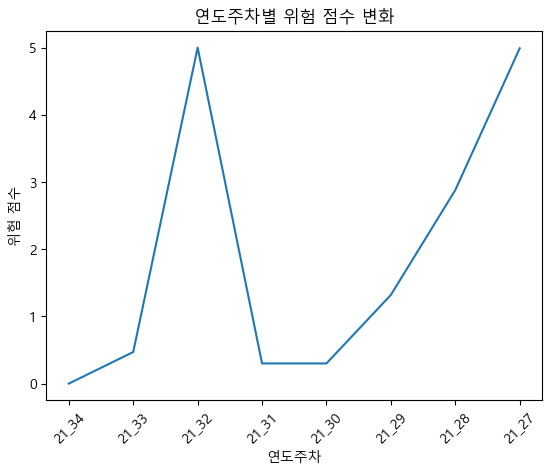

HS Code : 3104200000
         KOR_1  KOR_18     KOR_2       KOR_3  KOR_4  KOR_5  KOR_6  KOR_7  \
0   176219.674  22.144 19897.716  757442.376 24.874 23.804 23.932 21.040   
1   176454.419  22.213 20038.968  758508.890 24.938 23.915 23.795 20.332   
2   179603.742  22.655 20453.563  773293.021 25.346 24.272 24.264 20.891   
3   184012.793  23.273 21033.996  793990.805 25.916 24.772 24.919 21.674   
4   188421.845  23.892 21614.429  814688.589 26.487 25.272 25.575 22.458   
..         ...     ...       ...         ...    ...    ...    ...    ...   
292 301778.355  26.295 37153.516 1155595.203 30.423 33.799 19.898 21.937   
293 302764.441  26.423 37425.528 1161620.931 30.694 34.127 19.975 22.135   
294 304490.093  26.647 37901.548 1172165.954 31.169 34.701 20.111 22.481   
295 306215.744  26.871 38377.568 1182710.978 31.643 35.276 20.246 22.827   
296 307941.395  27.094 38853.588 1193256.001 32.118 35.850 20.382 23.173   

     KOR_8  KOR_9  ...      DJIA  NASDAQCOM   KOR_10  KOR_11  KOR_

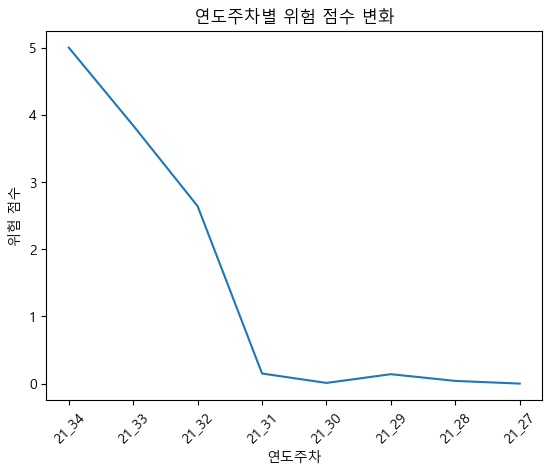

HS Code : 2905172000
         KOR_1  KOR_18     KOR_2       KOR_3  KOR_4  KOR_5  KOR_6  KOR_7  \
0   176219.674  22.144 19897.716  757442.376 24.874 23.804 23.932 21.040   
1   176454.419  22.213 20038.968  758508.890 24.938 23.915 23.795 20.332   
2   179603.742  22.655 20453.563  773293.021 25.346 24.272 24.264 20.891   
3   184012.793  23.273 21033.996  793990.805 25.916 24.772 24.919 21.674   
4   188421.845  23.892 21614.429  814688.589 26.487 25.272 25.575 22.458   
..         ...     ...       ...         ...    ...    ...    ...    ...   
292 301778.355  26.295 37153.516 1155595.203 30.423 33.799 19.898 21.937   
293 302764.441  26.423 37425.528 1161620.931 30.694 34.127 19.975 22.135   
294 304490.093  26.647 37901.548 1172165.954 31.169 34.701 20.111 22.481   
295 306215.744  26.871 38377.568 1182710.978 31.643 35.276 20.246 22.827   
296 307941.395  27.094 38853.588 1193256.001 32.118 35.850 20.382 23.173   

     KOR_8  KOR_9  ...      DJIA  NASDAQCOM   KOR_10  KOR_11  KOR_

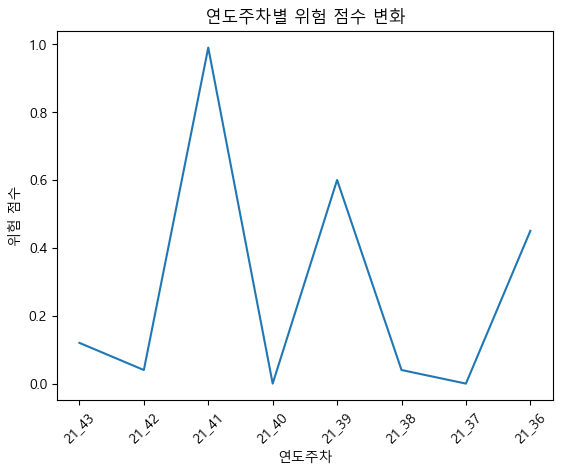

[0, 0, np.float64(4.46), np.float64(0.78), np.float64(0.01), 0, 0, np.float64(0.04), 0, np.float64(1.35), np.float64(0.1), 0, np.float64(3.5), 0, np.float64(0.12), np.float64(0.04), np.float64(1.35), np.float64(4.95), np.float64(1.35), 0, np.float64(0.01), 0, np.float64(4.99), np.float64(1.03), 0, 0, np.float64(3.06), np.float64(0.13), 0, np.float64(0.01), 0, np.float64(1.13), np.float64(2.11), np.float64(0.13), np.float64(0.43), np.float64(5.0), np.float64(3.49), np.float64(1.22), np.float64(5.0), np.float64(3.5), 0, np.float64(5.0), np.float64(0.24), np.float64(0.43), 0, np.float64(2.24), 0, np.float64(5.0), np.float64(5.0), np.float64(0.99)]
[0, 0, 49, 48, 43, 0, 0, 44, 0, 48, 48, 0, 47, 0, 44, 48, 46, 43, 45, 0, 45, 0, 44, 44, 0, 0, 45, 46, 0, 45, 0, 48, 46, 45, 49, 80, 197, 104, 78, 67, 0, 63, 62, 61, 0, 63, 0, 59, 57, 50]
DataFrame 길이: 15
리스트 k 길이: 50


In [ ]:
리스트 = pd.read_excel('c:\python\list(m).xlsx')
추출용 = 리스트.iloc[:,0].tolist()
리스트 = pd.read_excel('c:\python\list(m1).xlsx')
b = 리스트.iloc[:,0].tolist()

z = []
c = []
e = []
k = []
o = []
z_x = []
z_y = []

for i in range(0, len(추출용)):
  z.append(0) # 품목별 Highest CV를 반영하기 위해 List 생성
  c.append(0) # 품목별 CV값이 임계값 이상인 경우의 횟수를 반영하기 위한 List 생성
  k.append(0) # 임계값을 넘는 횟수
  o.append(0) # 위험경보 여부
  z_x.append(0) # Highest CV의 X값
  z_y.append(0) # Highest CV의 y값

for i in range(0, 8):
  e.append(0) # 품목별 8주간 CV값을 반영하기 위한 List 생성성
  
j = 0

for i in 추출용:
    print(f'HS Code : {i}')
    original[original['HS10단위부호'] == str(i)].sort_values(by = '수리일자', ascending = False)
    data = pd.DataFrame(columns = use_col)
    data = pd.concat([data, original[original['HS10단위부호'] == str(i)]])
    data = data.reset_index(drop=True)

    data = data.sort_values(by='수리일자', ascending=True).reset_index(drop=True)
    
    #
    ## 최근 52주간 수입단가(직전4주평균) 추이 파악
    #
    df_price = data[['연도주차', '과세가격미화금액', '신고중량']]
    df_price_week = df_price.groupby('연도주차')[['과세가격미화금액', '신고중량']].agg(['sum']).reset_index()
    df_price_week.columns = ['연도주차', '과세가격미화금액', '신고중량']


    # 수입이 없는 주차의 값을 0으로 생성
    df_price_week_hole = pd.DataFrame(columns = df_price_week.columns)
    for wk in set(date_index) - set(df_price_week['연도주차'].unique()):
        df_price_week_hole = pd.concat([df_price_week_hole, pd.DataFrame([{'연도주차': wk, '과세가격미화금액': 0, '신고중량': 0}])], ignore_index=True)
    df_price_week_total = pd.concat([df_price_week, df_price_week_hole]).sort_values('연도주차')

    # 해당 주차의 데이터를 직전 4주간 평균으로 대체
    price_w4 = []
    kg_w4 = []
    for x in range(0, len(df_price_week_total) - 3):
        price_w4.append(df_price_week_total[['과세가격미화금액']].iloc[x : x + 4].mean().iloc[0])
        kg_w4.append(df_price_week_total[['신고중량']].iloc[x : x + 4].mean().iloc[0])
    df_price_4w = df_price_week_total[3:]
    df_price_4w['과세가격미화금액'] = price_w4
    df_price_4w['신고중량'] = kg_w4
    df_price_4w = df_price_4w.reset_index(drop = True)
    df_price_4w['과세가격미화금액'] = df_price_4w['과세가격미화금액'].replace(0, np.nan).ffill()
    df_price_4w['신고중량'] = df_price_4w['신고중량'].replace(0, np.nan).ffill()
    df_price_4w['단가'] = df_price_4w['과세가격미화금액'] / df_price_4w['신고중량']
    df_price_4w = df_price_4w[['연도주차', '단가', '신고중량']]

    
    exog_w4 = []
    for x in range(0, len(exog_data) - 3):
        mean_vals = exog_data[x : x + 4].mean(axis=0)  # 각 열(column)에 대한 평균
        exog_w4.append(mean_vals)
        
    df_exog_4w = pd.DataFrame(exog_w4, columns=exog_columns)
    df_exog_4w = df_exog_4w.reset_index(drop=True)
    df_exog_4w = df_exog_4w.iloc[-len(df_price_4w):].reset_index(drop=True)
    print(df_exog_4w)
    
    X = df_exog_4w.select_dtypes(include=[np.number])
    scaler_exog_vif = StandardScaler()
    X_scaled = pd.DataFrame(scaler_exog_vif.fit_transform(X), columns=X.columns)   
    print("x", X_scaled) 

    y = df_price_4w['단가'].reset_index(drop=True)
    y1 = df_price_4w['신고중량'].reset_index(drop=True)
    scaler_y = StandardScaler()
    y_scaled = scaler_y.fit_transform(y.values.reshape(-1, 1)).flatten()    
    scaler_y1 = StandardScaler()
    y1_scaled = scaler_y1.fit_transform(y1.values.reshape(-1, 1)).flatten()

    # -----------------------------
    # 2. VIF 제거 (반복)
    # -----------------------------
    def calculate_vif(df):
        vif_data = pd.DataFrame()
        vif_data["Feature"] = df.columns
        vif_data["VIF"] = [variance_inflation_factor(df.values, i) for i in range(df.shape[1])]
        return vif_data

    X_vif = X_scaled.copy()
    while True:
        vif_df = calculate_vif(X_vif)
        max_vif = vif_df['VIF'].max()
        if max_vif > 10:
            drop_feature = vif_df.sort_values('VIF', ascending=False)['Feature'].iloc[0]
            print(f"VIF {max_vif:.2f}인 '{drop_feature}' 제거")
            X_vif = X_vif.drop(columns=drop_feature)
        else:
            break

    # -----------------------------
    # 3. OLS 회귀로 p-value 높은 변수 제거(단가)
    # -----------------------------
        
    # 함수 적용
    model, final_X = remove_high_pvalue_features(X_vif, pd.Series(y_scaled), threshold=0.1)

    # 결과 출력
    print("최종 변수 목록:", final_X.columns.tolist())
    print(model.summary())
    columns_without_const = [col for col in final_X.columns if col != 'const']
    if not columns_without_const:
        columns_without_const = ['KOR_1']
    df_exog_4w0 = df_exog_4w[columns_without_const].copy()
    
    # -----------------------------
    # 3. OLS 회귀로 p-value 높은 변수 제거(신고중량)
    # -----------------------------
        
    # 함수 적용
    model1, final_X1 = remove_high_pvalue_features(X_vif, pd.Series(y1_scaled), threshold=0.1)

    # 결과 출력
    print("최종 변수 목록:", final_X1.columns.tolist())
    print(model1.summary())
    columns_without_const1 = [col for col in final_X1.columns if col != 'const']
    if not columns_without_const1:
        columns_without_const1 = ['KOR_1']
    df_exog_4w1 = df_exog_4w[columns_without_const1].copy()
    
    
    for l in range(b[j]-8,b[j]):

        print(df_price_4w['연도주차'].iloc[-1-l] + '주차')
        #=================== 단가 percertile 구하기 ====================
        ecdf = ECDF(df_price_4w.iloc[p_eriod-l:-l]['단가'])
        y=np.exp((ecdf(df_price_4w.iloc[-1-l]['단가'])*100 - 95)*np.log(5)/5)

      #=================== 신고중량 ======================
         
        res_resid = df_price_4w['신고중량'].iloc[p_eriod-l:-l]
        res_resid = res_resid.reset_index(drop=True)
        exog_var = df_exog_4w1.iloc[p_eriod-l:-l]
        exog_var = exog_var.reset_index(drop=True)
        
        print(res_resid)
        print(exog_var)
        n_test = 1
        
        train_y, test_y = res_resid[:-n_test], res_resid[-n_test:]
        train_x, test_x = exog_var[:-n_test], exog_var[-n_test:]
        
        # 1) y와 X를 같이 붙여서 정리
        train_all = pd.concat(
            [pd.Series(train_y).rename('y'),
            pd.DataFrame(train_x).reset_index(drop=True)],
            axis=1
        )

        train_all = train_all.apply(pd.to_numeric, errors='coerce')
        train_all = train_all.replace([np.inf, -np.inf], np.nan)
        train_all = train_all.bfill().ffill().dropna().reset_index(drop=True)

        # test도 같은 방식
        test_all = pd.concat(
            [pd.Series(test_y).rename('y'),
            pd.DataFrame(test_x).reset_index(drop=True)],
            axis=1
        )

        test_all = test_all.apply(pd.to_numeric, errors='coerce')
        test_all = test_all.replace([np.inf, -np.inf], np.nan)
        test_all = test_all.bfill().ffill().dropna().reset_index(drop=True)

        # 2) 최소 길이 검사
        if len(train_all) < 10:
            print("train 데이터가 너무 짧아서 skip")
            continue

        # 3) y가 상수열이면 skip
        if train_all['y'].nunique() <= 1:
            print("train_y가 상수열이라 skip")
            continue

        # 4) 다시 분리
        train_y_clean = train_all['y']
        train_x_clean = train_all.drop(columns='y')

        test_y_clean = test_all['y']
        test_x_clean = test_all.drop(columns='y')

        # 5) 스케일링
        scaler_y = StandardScaler()
        scaler_x = StandardScaler()

        train_y_scaled = scaler_y.fit_transform(train_y_clean.values.reshape(-1, 1)).ravel()
        test_y_scaled  = scaler_y.transform(test_y_clean.values.reshape(-1, 1)).ravel()

        train_x_scaled = scaler_x.fit_transform(train_x_clean.values)
        test_x_scaled  = scaler_x.transform(test_x_clean.values)
        
        model = pm.auto_arima(train_y_scaled, exogenous=train_x_scaled, seasonal=False, trace=True)
        p, d, q = model.order

        model = SARIMAX(train_y_scaled, exog=train_x_scaled, order=(p, d, q), seasonal_order=(1, 1, 1, 12), 
                        enforce_stationarity=False, enforce_invertibility=False)
        model_fit = model.fit(disp=False)
        forecast1 = model_fit.forecast(steps=1, exog=test_x_scaled[-1:])
                
        print('======================= 여기부터 GARCH 모델링 =================================')
        est_residuals = model_fit.resid
        garch = arch.arch_model(est_residuals, vol="GARCH", p=1, q=1)
        garch_fit = garch.fit(disp="off", options={"maxiter": 1000})
        
        print('=========== GARCH forecast =============')
        garch_forecast = garch_fit.forecast(horizon = n_test, reindex=True)
        garch_std = np.sqrt(garch_forecast.variance.iloc[-1,0])
        stand_quant = (test_y_scaled[0] - forecast1[0])/ garch_std

        if(scipy.stats.norm.cdf(stand_quant)>0.5):
            x=np.exp((scipy.stats.norm.cdf(stand_quant)*100 - 95)*np.log(5)/5)
        else:
            x=np.exp(((1-scipy.stats.norm.cdf(stand_quant))*100 - 95)*np.log(5)/5)
        
        e[(l-b[j]+8)] = round(2/(1/y+1/x), 2)
        if(round(2/(1/y+1/x), 2)>1.85):
            k[j] += 1
        if(z[j] < round(2/(1/y+1/x), 2)):
            z[j] = round(2/(1/y+1/x), 2)
            c[j] = l
            
        if(z_x[j] < x):
            z_x[j] = x
            
        if(z_y[j] < y):
            z_y[j] = y
      
    if(z[j]>1.85):
        o[j] = 1
 
    import matplotlib.font_manager as fm

    plt.rc('font', family='Malgun Gothic')  # Windows (맑은 고딕)
    plt.rc('axes', unicode_minus=False)  # 마이너스(-) 기호 깨짐 방지
    
    x_labels = [df_price_4w['연도주차'].iloc[-1-l] for l in range(b[j]-8,b[j])]  # x축 라벨 생성
    plt.plot(x_labels, e)  # x축을 연도주차 값으로 설정
    plt.xticks(rotation=45)  # x축 라벨 회전 (가독성 개선)
    plt.xlabel("연도주차")  # x축 제목 추가
    plt.ylabel("위험 점수")  # y축 제목 추가
    plt.title("연도주차별 위험 점수 변화")  # 그래프 제목 추가
    plt.show()
    
    j += 1
print(z)
print(c)

print("DataFrame 길이:", len(collect['Model0(1)'].iloc[:-1]))
print("리스트 k 길이:", len(k))

# 구글드라이브에 있는 엑셀 파일을 불러와서 점수결과 저장하기
collect = pd.read_excel('c:\python\Compare_Models50.xlsx', sheet_name="점수")
collect = pd.DataFrame(collect)
collect.loc[:49, 'Model18(1)'] = o
collect.loc[50, 'Model18(1)'] = np.sum(o)
collect.loc[:49, 'Model18(2)'] = z
collect.loc[50, 'Model18(2)'] = np.mean(z)
collect.to_excel('c:\python\Compare_Models50.xlsx', sheet_name="점수", index=False)

collect1 = pd.read_excel('c:\python\Collectroc(t).xlsx', sheet_name="점수")
collect1 = pd.DataFrame(collect1)
collect1.loc[15:65, 'y_scores[19]'] = z
collect1.to_excel('c:\python\Collectroc(t).xlsx', sheet_name="점수", index=False)

collect2 = pd.read_excel('c:\python\Collectroc(x).xlsx', sheet_name="점수")
collect2 = pd.DataFrame(collect2)
collect2.loc[15:65, 'y_scores[19]'] = z_x
collect2.to_excel('c:\python\Collectroc(x).xlsx', sheet_name="점수", index=False)

collect3 = pd.read_excel('c:\python\Collectroc(y).xlsx', sheet_name="점수")
collect3 = pd.DataFrame(collect3)
collect3.loc[15:65, 'y_scores[19]'] = z_y
collect3.to_excel('c:\python\Collectroc(y).xlsx', sheet_name="점수", index=False)